<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/Synthetic_Respondents_VCIOM_FINAL_SAFE_FAST2X_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Синтетические респонденты на открытых микроданных ВЦИОМ

**Финальный воспроизводимый эксперимент: same-wave, temporal OOD, thematic OOD и sequential respondent · SAFE FAST-2X V3 · resumable L4 profile**

Ноутбук предназначен для Google Colab с GPU NVIDIA T4/L4. Содержательные задачи задаются только вручную в `TASK_SPECS`. Для заранее проверенных случаев физическое имя SPSS-переменной фиксируется в ручном `TARGET_VARIABLE_HINTS`; во всех остальных случаях target разрешается только по единственному совпадению заранее заданной метки. Metadata используется для валидации, но никогда не для автоматического выбора другого содержательного вопроса.

Основной вопрос: насколько synthetic respondents на базе открытой `Qwen/Qwen3-8B`, включая QLoRA, воспроизводят индивидуальные ответы, агрегированные распределения, межгрупповые различия, структуру связей и перенос на новые волны/темы — и как они соотносятся с empirical prior, Logistic Regression, CatBoost и LightGBM.

**Критерий эквивалентности на задаче:** одновременно `TVD ≤ 0.05` и `max_pp ≤ 5 п.п.`; для финального вывода верхняя граница 95% bootstrap CI также должна оставаться внутри обоих порогов. Эквивалентность не предполагается заранее.


**Надёжность выполнения.** Длительные стадии разбиты на атомарные подэтапы. После каждого QLoRA seed, каждой bootstrap-задачи и каждого robustness/rectification подэтапа состояние сохраняется локально в runtime атомарной записью. Прерывание одной ячейки не аннулирует завершённые подэтапы: повторный запуск этой же ячейки продолжает с последнего валидного checkpoint. Google Drive не используется.


In [1]:
import sys, subprocess
PKGS=[
    "transformers==5.17.0","peft==0.21.0","bitsandbytes==0.50.2","accelerate==1.15.0",
    "huggingface_hub>=1.23,<2","pyreadstat>=1.3","catboost>=1.2","lightgbm>=4.3",
    "scikit-learn>=1.6,<2","openpyxl>=3.1","pyarrow>=18","beautifulsoup4>=4.12",
    "requests>=2.32","scipy>=1.14","matplotlib>=3.9","tqdm>=4.67","liger-kernel==0.8.3"
]
subprocess.check_call([sys.executable,"-m","pip","install","-q","-U",*PKGS])


0

In [2]:
from __future__ import annotations

import os, re, gc, sys, json, math, time, random, shutil, hashlib, inspect, platform, subprocess, warnings, zipfile, difflib, itertools, importlib.metadata as importlib_metadata
os.environ['TOKENIZERS_PARALLELISM']='false'; os.environ['WANDB_DISABLED']='true'; os.environ['HF_HUB_DISABLE_PROGRESS_BARS']='1'; os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF','expandable_segments:True')
from pathlib import Path
from urllib.parse import urljoin, urlparse, unquote
from collections import defaultdict, deque
from dataclasses import dataclass
from typing import Any

import numpy as np, pandas as pd, requests, pyreadstat
from bs4 import BeautifulSoup
from scipy.special import softmax
from scipy.optimize import minimize_scalar
from scipy.stats import t as student_t, chi2_contingency
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

import torch, torch.nn.functional as F, transformers, peft, bitsandbytes, accelerate
from transformers import AutoConfig, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, Trainer, TrainerCallback, TrainingArguments
from peft import LoraConfig, get_peft_model, PeftModel
from liger_kernel.transformers import apply_liger_kernel_to_qwen3

warnings.filterwarnings('ignore',category=FutureWarning); transformers.utils.logging.set_verbosity_error()
PROTOCOL_VERSION='SAFE_FAST2X_V3_20260918'
LIGER_ENABLED=False
try:
    apply_liger_kernel_to_qwen3(rope=True,swiglu=True,rms_norm=True,cross_entropy=False,fused_linear_cross_entropy=False); LIGER_ENABLED=True
except TypeError:
    apply_liger_kernel_to_qwen3(); LIGER_ENABLED=True
except Exception as _liger_err:
    warnings.warn(f'Liger Kernel не активирован; notebook продолжит на стандартном SDPA: {_liger_err}')

# Только локальная файловая система runtime. НИЧЕГО не удаляем автоматически: это принципиально для resume после остановленной ячейки.
ROOT=Path('/content/vciom_synthetic_respondents') if Path('/content').exists() else Path.cwd()/'vciom_synthetic_respondents'
DATA_DIR=ROOT/'data'; OUT_DIR=ROOT/f'outputs_{PROTOCOL_VERSION}'; FIG_DIR=OUT_DIR/'figures'; CHECKPOINT_DIR=OUT_DIR/'checkpoints'; ADAPTER_ROOT=OUT_DIR/'adapters'
for p in [DATA_DIR,OUT_DIR,FIG_DIR,CHECKPOINT_DIR,ADAPTER_ROOT]: p.mkdir(parents=True,exist_ok=True)

def atomic_write_text(path:Path,text:str):
    path=Path(path); path.parent.mkdir(parents=True,exist_ok=True); tmp=path.with_name(path.name+'.tmp')
    tmp.write_text(text,encoding='utf-8'); os.replace(tmp,path)
def atomic_write_json(path:Path,obj): atomic_write_text(path,json.dumps(obj,ensure_ascii=False,indent=2,default=str))
def atomic_to_parquet(df:pd.DataFrame,path:Path):
    path=Path(path); path.parent.mkdir(parents=True,exist_ok=True); tmp=path.with_name(path.stem+'.tmp.parquet')
    df.to_parquet(tmp,index=False); os.replace(tmp,path)
def safe_read_parquet(path:Path,columns=None):
    path=Path(path); return pd.read_parquet(path,columns=columns) if path.exists() else None

def stable_hash(obj)->str: return hashlib.sha256(json.dumps(obj,ensure_ascii=False,sort_keys=True,default=str).encode()).hexdigest()

def checkpoint_df(name:str,df:pd.DataFrame,folder:Path=CHECKPOINT_DIR): atomic_to_parquet(df,Path(folder)/f'{name}.parquet')
def load_checkpoint_df(name:str,folder:Path=CHECKPOINT_DIR): return safe_read_parquet(Path(folder)/f'{name}.parquet')

MASTER_SEED=20250301
SEEDS=[20250301,20250311,20250321,20250401,20250411,20250421,20250501,20250511,20250521,20250601]
CANONICAL_SEED=SEEDS[0]; MODEL_ID='Qwen/Qwen3-8B'; EQUIV_TVD=0.05; EQUIV_MAX_PP=5.0; BOOTSTRAP_B=1000; RECTIFICATION_B=200; EPOCH2_MATERIAL_TVD=0.010

def seed_everything(seed:int)->None:
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
seed_everything(MASTER_SEED)
if not torch.cuda.is_available(): raise RuntimeError('Для основного эксперимента требуется CUDA GPU (Colab T4/L4).')
GPU_NAME=torch.cuda.get_device_name(0); GPU_KIND='L4' if 'L4' in GPU_NAME.upper() else ('T4' if 'T4' in GPU_NAME.upper() else 'OTHER')
COMPUTE={
 'T4':dict(hp_train_pairs=256,final_train_pairs=640,hp_val_n_per_task=64,cal_val_n_per_task=160,eval_n_per_task=160,seed_eval_n_per_task=64,seq_n=48,perturb_n=70,max_length=512,train_bs=2,grad_accum=8,infer_bs=16,effective_batch=16,train_candidates=[(2,8,True),(1,16,False),(1,16,True)]),
 'L4':dict(hp_train_pairs=384,final_train_pairs=896,hp_val_n_per_task=96,cal_val_n_per_task=240,eval_n_per_task=300,seed_eval_n_per_task=80,seq_n=96,perturb_n=120,max_length=512,train_bs=4,grad_accum=4,infer_bs=32,effective_batch=16,train_candidates=[(4,4,True),(2,8,False),(2,8,True),(1,16,False),(1,16,True)]),
 'OTHER':dict(hp_train_pairs=320,final_train_pairs=768,hp_val_n_per_task=80,cal_val_n_per_task=180,eval_n_per_task=200,seed_eval_n_per_task=72,seq_n=60,perturb_n=80,max_length=512,train_bs=2,grad_accum=8,infer_bs=16,effective_batch=16,train_candidates=[(2,8,True),(1,16,False),(1,16,True)])}[GPU_KIND]
DTYPE=torch.bfloat16 if GPU_KIND=='L4' and torch.cuda.is_bf16_supported() else torch.float16; BF16=DTYPE==torch.bfloat16; FP16=DTYPE==torch.float16
if torch.cuda.get_device_capability(0)[0]>=8: torch.backends.cuda.matmul.allow_tf32=True
try: torch.backends.cuda.enable_flash_sdp(True); torch.backends.cuda.enable_mem_efficient_sdp(True); torch.backends.cuda.enable_math_sdp(True)
except Exception: pass

PINNED={'transformers':'5.17.0','peft':'0.21.0','bitsandbytes':'0.50.2','accelerate':'1.15.0','liger-kernel':'0.8.3'}
for pkg,expected in PINNED.items():
    got=importlib_metadata.version(pkg)
    if got!=expected: raise RuntimeError(f'Версия {pkg}={got}, ожидалась {expected}. Перезапустите runtime и выполните notebook сверху.')
for mod,expected in [(transformers,PINNED['transformers']),(peft,PINNED['peft']),(bitsandbytes,PINNED['bitsandbytes']),(accelerate,PINNED['accelerate'])]:
    got=getattr(mod,'__version__',None)
    if got and str(got)!=expected: raise RuntimeError(f'В памяти загружена старая версия {mod.__name__}={got}, а установлена {expected}. Сделайте Runtime → Restart session и запустите сверху.')

PROGRESS_STAGES={'resources':(1,'Ресурсы и микроданные',0,35),'registry':(2,'TASK REGISTRY и SPSS metadata',35,55),'frames':(3,'Выборки и respondent-level split',55,72),'gate':(4,'Anti-leakage validation gate',72,82),'base':(5,'Base Qwen: 3 режима',82,195),'hp':(6,'QLoRA sensitivity',195,365),'main':(7,'ML + 10 QLoRA seeds + canonical',365,875),'equiv':(8,'Bootstrap equivalence',875,925),'robust':(9,'Robustness и rectification',925,980),'save':(10,'Фигуры и сохранение',980,1000)}
RUN_STARTED=time.time()
def _fmt_seconds(x):
    if x is None or not np.isfinite(x) or x<0: return '—'
    x=int(round(x)); h,x=divmod(x,3600); m,s=divmod(x,60); return f'{h:02d}:{m:02d}:{s:02d}' if h else f'{m:02d}:{s:02d}'
RUN_PROGRESS=tqdm(total=1000,desc='00/10 Инициализация',leave=True,dynamic_ncols=True,mininterval=.4,bar_format='{desc} |{bar:28}| {percentage:3.0f}% | {postfix}')
def _vram_text():
    try: return f' · VRAM {torch.cuda.memory_allocated()/1024**3:.1f}/{torch.cuda.get_device_properties(0).total_memory/1024**3:.1f}G'
    except Exception: return ''
def progress_set(key:str,fraction:float=0.0,detail:str='',eta_seconds:float|None=None):
    idx,label,start,end=PROGRESS_STAGES[key]; fraction=float(np.clip(fraction,0,1)); target=max(int(RUN_PROGRESS.n),int(round(start+(end-start)*fraction)))
    RUN_PROGRESS.set_description_str(f'{idx:02d}/10 {label}'+(f' · {detail}' if detail else ''),refresh=False)
    RUN_PROGRESS.set_postfix_str(f'{_fmt_seconds(time.time()-RUN_STARTED)} прошло'+(f' · ETA {_fmt_seconds(eta_seconds)}' if eta_seconds is not None else '')+_vram_text(),refresh=False)
    delta=target-int(RUN_PROGRESS.n); RUN_PROGRESS.update(delta) if delta>0 else RUN_PROGRESS.refresh()
def progress_done():
    RUN_PROGRESS.set_description_str('10/10 Готово',refresh=False); RUN_PROGRESS.set_postfix_str(f'{_fmt_seconds(time.time()-RUN_STARTED)} всего',refresh=False); RUN_PROGRESS.update(max(0,1000-int(RUN_PROGRESS.n))); RUN_PROGRESS.close()


00/10 Инициализация |                            |   0% | 

## Метрики и статистический критерий

Для наблюдаемого распределения $p=(p_1,\dots,p_K)$ и синтетического распределения $q=(q_1,\dots,q_K)$:

$$\mathrm{TVD}(p,q)=\frac12\sum_{k=1}^K|p_k-q_k|.$$

Дополнительно сохраняется Jensen–Shannon divergence:

$$\mathrm{JSD}(p,q)=\frac12D_{KL}(p\|m)+\frac12D_{KL}(q\|m),\qquad m=\frac{p+q}{2}.$$

Многоклассовый Brier score:

$$\mathrm{Brier}=\frac{1}{N}\sum_{i=1}^N\sum_{k=1}^K(\hat p_{ik}-y_{ik})^2.$$

Expected Calibration Error при разбиении прогнозов по уверенности на $B$ интервалов:

$$\mathrm{ECE}=\sum_{b=1}^B\frac{|I_b|}{N}\left|\operatorname{acc}(I_b)-\operatorname{conf}(I_b)\right|.$$

Для каждого класса $k$ вычисляется $F1_k=2P_kR_k/(P_k+R_k)$, после чего

$$\mathrm{Macro\text{-}F1}=\frac{1}{K}\sum_{k=1}^K F1_k.$$

Доверительный интервал для population-level метрик строится непараметрическим bootstrap респондентов. Если $\hat\theta^{*(1)},\ldots,\hat\theta^{*(B)}$ — bootstrap-оценки, то

$$CI_{0.95}=\left[Q_{0.025}\left(\hat\theta^*\right),\;Q_{0.975}\left(\hat\theta^*\right)\right].$$

Эквивалентность на задаче фиксируется только тогда, когда одновременно выполняются

$$\mathrm{TVD}\le 0.05,\qquad \max_k|p_k-q_k|\times100\le5\ \text{п.п.},$$

и верхние границы соответствующих 95% bootstrap CI не выходят за эти пределы.

Для rectification используется prediction-powered поправка распределения:

$$\hat\mu_{\mathrm{rect}}=\frac1N\sum_{i=1}^N\hat f(X_i)+\frac1n\sum_{j=1}^n\{Y_j-\hat f(X_j)\},$$

после чего вектор ограничивается симплексом вероятностей. В коде применяется взвешенная версия, когда официальный массив содержит валидный survey weight.

## Экспериментальный протокол

**Что проверяется.** В `same-wave` один физический массив делится по респондентам на train/validation/test; один респондент не может оказаться в нескольких split. В `temporal OOD` обучение идет только на волне $t_1$, а соответствующая волна $t_2$ целиком остается тестовой. Используются две независимые временные пары: социальное самочувствие (2024→2025) и счастье (2024→2025). В `thematic OOD` весь массив об этике ИИ исключен из SFT. В `sequential respondent` ответы на несколько вопросов одного массива формируются последовательно с историей собственных предыдущих ответов модели.

**Почему так.** Такая схема отделяет запоминание распределений текущей волны от переноса во времени и на новую тему. Целевые вопросы задаются только вручную; для проверенных массивов разрешены фиксированные физические имена SPSS-переменных, после чего metadata обязательно валидирует их семантику и категории. Fuzzy/semantic autoselection target запрещён.

**Выбор модели.** QLoRA-гиперпараметры и temperature calibration используют только validation. После выбора одной конфигурации выполняются ровно 10 seed-runs при неизменных TASK REGISTRY, split и составе SFT-подвыборки. Полный bootstrap и дорогие проверки выполняются на заранее фиксированном canonical seed.

**Успех.** Основная population-level метрика — TVD. Строгая статистическая эквивалентность фиксируется только по критерию ниже и только если 95%-й bootstrap-ДИ не выходит за заданные границы; отсутствие эквивалентности является допустимым научным результатом.

### Сквозной индикатор выполнения

В ходе запуска отображается **один** progress bar. В его подписи всегда указан текущий этап; справа — прошедшее и оценочное оставшееся время. Этапы: **1)** ресурсы и микроданные; **2)** реестр задач и SPSS-метаданные; **3)** выборки и respondent-level split; **4)** anti-leakage gate; **5)** три режима base Qwen; **6)** coarse-to-fine QLoRA selection; **7)** ML-baselines, 10 QLoRA seeds и canonical model; **8)** bootstrap equivalence; **9)** subgroup/order/sequential/association/rectification; **10)** четыре фигуры и сохранение результатов. Внутренние progress bars отключены, чтобы не засорять output.


### FAST-2X EXACT вычислительный протокол

Ускорение выполняется **без сокращения научного дизайна**: на L4 сохраняются 10 независимых seed-runs, тот же фиксированный SFT-пул из 896 пар, 1 epoch, эффективный batch 16, те же validation/test/OOD-респонденты, полный canonical analysis, survey weights, subgroup/association checks и bootstrap $B=1000$.

Вычислительный выигрыш достигается четырьмя техническими приёмами, не меняющими данные и критерии: **(1)** точные Liger/Triton kernels для Qwen3 (`RMSNorm`, `RoPE`, `SwiGLU`); **(2)** один 4-bit base Qwen загружается в GPU один раз и между независимыми LoRA-прогонами adapters удаляются через `PeftModel.unload()` без merge, поэтому frozen base не переинициализируется и не копируется; **(3)** micro-batch подбирается коротким L4 memory-probe, при этом effective batch всегда остаётся равным 16; **(4)** inference объединяет фиксированные задачи в крупные length-sorted batches и автоматически уменьшает batch только при OOM. Успешные inference-вызовы больше не делают `empty_cache()`, что устраняет лишнюю синхронизацию GPU.

Hyperparameter sensitivity остаётся validation-only: 3 learning rates, 2 LoRA ranks и отдельная проверка 2 epochs выполняются на фиксированных 384 SFT-парах. Temperature scaling по-прежнему оценивается только для canonical seed. Completion-only SFT остаётся точным next-token loss для реального токена ответа A/B/C/… с `logits_to_keep=1`; содержательная постановка модели не меняется.

Почти полностью занятая VRAM сама по себе не считается ошибкой: PyTorch и CUDA используют свободную память под рабочие буферы и cache. В progress bar выводится **allocated VRAM**, а memory-probe оставляет резерв перед началом серийных прогонов. Google Drive не подключается; seed-cache и итоговые файлы хранятся только в локальной файловой системе runtime.


**Защита от прерывания.** Завершённые QLoRA seeds, bootstrap-задачи и robustness-подэтапы фиксируются атомарно в локальном runtime. В отличие от предыдущей версии, `Robustness/rectification` не является одной монолитной ячейкой: rectification имеет отдельную ячейку и checkpoint после каждой задачи. Если её остановить, повторный запуск продолжит только недосчитанные задачи.


In [3]:
# Официальные страницы ВЦИОМ. Микроданные разрешаются только через ссылку «Массив данных» на каждой странице.
DATASETS = {
    'social_2024': {
        'title': 'Социальное самочувствие, 2024',
        'article_url': 'https://wciom.ru/analytical-reviews/analiticheskii-obzor/socialnoe-samochuvstvie-monitoring-20032024',
        'year': 2024, 'temporal_test': False, 'thematic_ood': False,
    },
    'social_2025': {
        'title': 'Социальное самочувствие россиян: мониторинг, 2025',
        'article_url': 'https://wciom.ru/analytical-reviews/analiticheskii-obzor/socialnoe-samochuvstvie-rossijan-monitoring-27052025',
        'year': 2025, 'temporal_test': True, 'thematic_ood': False,
    },
    'ai_ethics_2024': {
        'title': 'Этика искусственного интеллекта, 2024',
        'article_url': 'https://wciom.ru/analytical-reviews/analiticheskii-obzor/ehtika-iskusstvennogo-intellekta-2',
        'year': 2024, 'temporal_test': False, 'thematic_ood': True,
    },
    'family_2024': {
        'title': 'Семья в системе ценностей россиян, 2024',
        'article_url': 'https://wciom.ru/analytical-reviews/analiticheskii-obzor/semja-v-sisteme-cennostei-rossijan',
        'year': 2024, 'temporal_test': False, 'thematic_ood': False,
    },
    'happiness_2024': {
        'title': 'Счастье в России: мониторинг, 2024',
        'article_url': 'https://wciom.ru/analytical-reviews/analiticheskii-obzor/schaste-v-rossii-monitoring-18042024',
        'year': 2024, 'temporal_test': False, 'thematic_ood': False,
    },
    'happiness_2025': {
        'title': 'Счастье в России: мониторинг, 2025',
        'article_url': 'https://wciom.ru/analytical-reviews/analiticheskii-obzor/schaste-v-rossii-monitoring-16042025',
        'year': 2025, 'temporal_test': True, 'thematic_ood': False,
    },
}

# ВАЖНО: это ручной содержательный registry. Код не ищет «подходящие» вопросы и не заменяет их другими.
# answer_options — канонические варианты. option_aliases допускают только заранее перечисленные варианты написания metadata.
TASK_SPECS = [{'task_id': 'SOC_LIFE_2024',
  'dataset_id': 'social_2024',
  'type': 'single_choice',
  'regime': 'same_wave',
  'train_test_status': 'train/val/test; temporal source',
  'temporal_counterpart': 'SOC_LIFE_2025',
  'question_text': 'В какой мере Вас устраивает жизнь, которую Вы сейчас ведете?',
  'label_any_of': ['В какой мере Вас устраивает жизнь, которую Вы сейчас ведете?'],
  'answer_options': ['Вполне устраивает',
                     'По большей части устраивает',
                     'Отчасти устраивает, отчасти нет',
                     'По большей части не устраивает',
                     'Совершенно не устраивает',
                     'Затрудняюсь ответить'],
  'option_aliases': [['Вполне устраивает'],
                     ['По большей части устраивает'],
                     ['Отчасти устраивает, отчасти нет'],
                     ['По большей части не устраивает'],
                     ['Совершенно не устраивает'],
                     ['Затрудняюсь ответить']],
  'reason': 'базовый индикатор социального самочувствия; повторяется между волнами'},
 {'task_id': 'SOC_LIFE_2025',
  'dataset_id': 'social_2025',
  'type': 'single_choice',
  'regime': 'temporal_ood',
  'train_test_status': 'test only',
  'temporal_counterpart': 'SOC_LIFE_2024',
  'question_text': 'В какой мере Вас устраивает жизнь, которую Вы сейчас ведете?',
  'label_any_of': ['В какой мере Вас устраивает жизнь, которую Вы сейчас ведете?'],
  'answer_options': ['Вполне устраивает',
                     'По большей части устраивает',
                     'Отчасти устраивает, отчасти нет',
                     'По большей части не устраивает',
                     'Совершенно не устраивает',
                     'Затрудняюсь ответить'],
  'option_aliases': [['Вполне устраивает'],
                     ['По большей части устраивает'],
                     ['Отчасти устраивает, отчасти нет'],
                     ['По большей части не устраивает'],
                     ['Совершенно не устраивает'],
                     ['Затрудняюсь ответить']],
  'reason': 'полностью новая временная волна для temporal OOD'},
 {'task_id': 'HAPPY_2024',
  'dataset_id': 'happiness_2024',
  'type': 'single_choice',
  'regime': 'same_wave',
  'train_test_status': 'train/val/test; temporal source',
  'temporal_counterpart': 'HAPPY_2025',
  'question_text': 'В жизни бывает всякое — и хорошее, и плохое. Но если говорить в целом, Вы счастливы или нет?',
  'label_any_of': ['В жизни бывает всякое — и хорошее, и плохое. Но если говорить в целом, Вы счастливы или нет?',
                   'В жизни бывает всякое - и хорошее, и плохое. Но если говорить в целом, Вы счастливы или нет?',
                   'В жизни бывает всякое и хорошее, и плохое. Но если говорить в целом, Вы счастливы или нет?'],
  'answer_options': ['Определенно да', 'Скорее да', 'Скорее нет', 'Определенно нет', 'Затрудняюсь ответить'],
  'option_aliases': [['Определенно да', 'Да, определенно'],
                     ['Скорее да'],
                     ['Скорее нет'],
                     ['Определенно нет', 'Нет, определенно'],
                     ['Затрудняюсь ответить']],
  'reason': 'дополнительная независимая temporal-пара мониторингового вопроса'},
 {'task_id': 'HAPPY_2025',
  'dataset_id': 'happiness_2025',
  'type': 'single_choice',
  'regime': 'temporal_ood',
  'train_test_status': 'test only',
  'temporal_counterpart': 'HAPPY_2024',
  'question_text': 'В жизни бывает всякое — и хорошее, и плохое. Но если говорить в целом, Вы счастливы или нет?',
  'label_any_of': ['В жизни бывает всякое — и хорошее, и плохое. Но если говорить в целом, Вы счастливы или нет?',
                   'В жизни бывает всякое - и хорошее, и плохое. Но если говорить в целом, Вы счастливы или нет?',
                   'В жизни бывает всякое и хорошее, и плохое. Но если говорить в целом, Вы счастливы или нет?'],
  'answer_options': ['Определенно да', 'Скорее да', 'Скорее нет', 'Определенно нет', 'Затрудняюсь ответить'],
  'option_aliases': [['Определенно да', 'Да, определенно'],
                     ['Скорее да'],
                     ['Скорее нет'],
                     ['Определенно нет', 'Нет, определенно'],
                     ['Затрудняюсь ответить']],
  'reason': 'полностью новая временная волна для temporal OOD'},
 {'task_id': 'FAMILY_STRONG_2024',
  'dataset_id': 'family_2024',
  'type': 'single_choice_matrix_row',
  'regime': 'same_wave',
  'train_test_status': 'train/val/test',
  'temporal_counterpart': None,
  'question_text': 'Оцените важность для Вас следующих ценностей по 7-балльной шкале, где «1» – совсем не важный принцип, ценность, а «7» – очень важный принцип [строка: Крепкая семья].',
  'label_any_of': ['Крепкая семья', 'Крепкая семья.'],
  'answer_options': ['1 – совсем не важный принцип, ценность', '2,00', '3,00', '4,00', '5,00', '6,00', '7 – очень важный принцип, ценность', 'Затрудняюсь ответить'],
  'option_aliases': [['1',
                      '1,00',
                      '1.00',
                      '1 – совсем не важный принцип, ценность',
                      '1 — совсем не важный принцип, ценность',
                      '1 — совсем не важная ценность'],
                     ['2', '2,00', '2.00'],
                     ['3', '3,00', '3.00'],
                     ['4', '4,00', '4.00'],
                     ['5', '5,00', '5.00'],
                     ['6', '6,00', '6.00'],
                     ['7', '7,00', '7.00', '7 – очень важный принцип, ценность', '7 — очень важный принцип, ценность', '7 — очень важная ценность'],
                     ['Затрудняюсь ответить']],
  'reason': 'индивидуальная ценностная оценка; одна строка шкальной матрицы, не multiple-response dummy'},
 {'task_id': 'AI_SCOPE_2024',
  'dataset_id': 'ai_ethics_2024',
  'type': 'single_choice',
  'regime': 'thematic_ood',
  'train_test_status': 'test only; dataset excluded from SFT',
  'temporal_counterpart': None,
  'question_text': 'Поговорим об искусственном интеллекте. Это компьютерные программы, которые выполняют сложные задачи, которые когда-то требовали участия человека, например общение с клиентами в интернете, создание иллюстраций, принятие решений на основе данных и многое другое. Что Вы думаете о применении искусственного интеллекта в различных сферах жизни?',
  'label_any_of': ['Что Вы думаете о применении искусственного интеллекта в различных сферах жизни?',
                   'Поговорим об искусственном интеллекте. Что Вы думаете о применении искусственного интеллекта в различных сферах жизни?',
                   'Поговорим об искусственном интеллекте. Это компьютерные программы, которые выполняют сложные задачи, которые когда-то требовали участия человека, например общение с клиентами в интернете, создание иллюстраций, принятие решений на основе данных и многое другое. Что Вы думаете о применении искусственного интеллекта в различных сферах жизни?'],
  'answer_options': ['Искусственный интеллект должен использоваться во всех возможных сферах',
                     'Искусственный интеллект следует использовать только в некоторых сферах',
                     'Искусственный интеллект не должен использоваться вообще',
                     'Затрудняюсь ответить'],
  'option_aliases': [['Искусственный интеллект должен использоваться во всех возможных сферах', 'Использовать во всех возможных сферах'],
                     ['Искусственный интеллект следует использовать только в некоторых сферах', 'Использовать только в некоторых сферах'],
                     ['Искусственный интеллект не должен использоваться вообще', 'Не использовать вообще'],
                     ['Затрудняюсь ответить']],
  'reason': 'содержательно новая тема, полностью исключенная из SFT'},
 {'task_id': 'AI_HUMAN_2024',
  'dataset_id': 'ai_ethics_2024',
  'type': 'single_choice',
  'regime': 'thematic_ood',
  'train_test_status': 'test only; dataset excluded from SFT',
  'temporal_counterpart': None,
  'question_text': 'Какая точка зрения об этике и искусственном интеллекте Вам ближе?',
  'label_any_of': ['Какая точка зрения об этике и искусственном интеллекте Вам ближе?'],
  'answer_options': ['Искусственный интеллект можно научить быть этичным и всегда учитывать нормы морали в своих решениях',
                     'Требуется обязательное участие человека в оценке этичности продуктов и решений, созданных искусственным интеллектом, сам искусственный интеллект на такое не способен',
                     'Затрудняюсь ответить'],
  'option_aliases': [['Искусственный интеллект можно научить быть этичным и всегда учитывать нормы морали в своих решениях'],
                     ['Требуется обязательное участие человека в оценке этичности продуктов и решений, созданных искусственным интеллектом, сам '
                      'искусственный интеллект на такое не способен'],
                     ['Затрудняюсь ответить']],
  'reason': 'тематический OOD: нормативная граница автономии ИИ'},
 {'task_id': 'AI_MARK_2024',
  'dataset_id': 'ai_ethics_2024',
  'type': 'single_choice',
  'regime': 'thematic_ood',
  'train_test_status': 'test only; dataset excluded from SFT',
  'temporal_counterpart': None,
  'question_text': 'А как Вы думаете, необходимо или нет маркировать особым образом продукты, изображения и решения, созданные искусственным '
                   'интеллектом или при его помощи?',
  'label_any_of': ['А как Вы думаете, необходимо или нет маркировать особым образом продукты, изображения и решения, созданные искусственным '
                   'интеллектом или при его помощи?',
                   'необходимо или нет маркировать особым образом продукты, изображения и решения, созданные искусственным интеллектом или при его '
                   'помощи?'],
  'answer_options': ['Да', 'Скорее да', 'Скорее нет', 'Нет', 'Затрудняюсь ответить'],
  'option_aliases': [['Да'], ['Скорее да'], ['Скорее нет'], ['Нет'], ['Затрудняюсь ответить']],
  'reason': 'тематический OOD: маркировка ИИ-контента'},
 {'task_id': 'AI_CODE_2024',
  'dataset_id': 'ai_ethics_2024',
  'type': 'single_choice',
  'regime': 'thematic_ood',
  'train_test_status': 'test only; dataset excluded from SFT',
  'temporal_counterpart': None,
  'question_text': 'Как Вы считаете, для организаций, ведущих разработки в сфере искусственного интеллекта, нужен или нет свод правил этики в сфере искусственного интеллекта? И если нужен, то он должен носить добровольный и рекомендательный характер или обязательный и предписывающий?',
  'label_any_of': ['Как Вы считаете, для организаций, ведущих разработки в сфере искусственного интеллекта, нужен или нет свод правил этики в сфере искусственного интеллекта? И если нужен, то он должен носить добровольный и рекомендательный характер или обязательный и предписывающий?'],
  'answer_options': ['Нужен свод правил этики, но добровольный и рекомендательный',
                     'Нужен свод правил этики, причем обязательный для всех',
                     'Не нужен свод правил этики',
                     'Затрудняюсь ответить'],
  'option_aliases': [['Нужен свод правил этики, но добровольный и рекомендательный'],
                     ['Нужен свод правил этики, причем обязательный для всех', 'Нужен свод правил этики, причём обязательный для всех'],
                     ['Не нужен свод правил этики'],
                     ['Затрудняюсь ответить']],
  'reason': 'тематический OOD: институциональные нормы разработки ИИ'}]

# Контекст RAG содержит только сведения об источнике/режиме, но не распределения ответов.
RAG_CONTEXTS = {
    'social_2024':'Источник: открытый массив ВЦИОМ 2024 года о социальном самочувствии взрослых россиян.',
    'social_2025':'Источник: новая открытая волна ВЦИОМ 2025 года о социальном самочувствии взрослых россиян.',
    'family_2024':'Источник: открытое исследование ВЦИОМ 2024 года о семье и ценностях россиян.',
    'happiness_2024':'Источник: открытый мониторинг ВЦИОМ 2024 года о субъективном ощущении счастья.',
    'happiness_2025':'Источник: новая открытая волна мониторинга ВЦИОМ 2025 года о субъективном ощущении счастья.',
    'ai_ethics_2024':'Источник: открытое исследование ВЦИОМ 2024 года об этике искусственного интеллекта.',
}

In [4]:
def canon(s:Any)->str:
    s='' if s is None else str(s)
    s=s.replace('ё','е').replace('Ё','Е').strip().lower()
    s=re.sub(r'^\s*[a-zа-я_]+\d+(?:[._]\d+)*\s*[.):-]?\s*','',s,flags=re.I)
    s=re.sub(r'^\s*(?:q|v|вопрос)\s*\d+(?:[._]\d+)*\s*[.):-]?\s*','',s,flags=re.I)
    s=re.sub(r'[«»“”„"]','',s); s=re.sub(r'[?!.,:;–—-]+',' ',s); s=re.sub(r'\s+',' ',s)
    return s.strip()

def sha256_file(path:Path)->str:
    h=hashlib.sha256()
    with open(path,'rb') as f:
        for chunk in iter(lambda:f.read(1024*1024),b''): h.update(chunk)
    return h.hexdigest()

def _official_host(url:str)->bool:
    host=(urlparse(url).hostname or '').lower()
    return host=='wciom.ru' or host.endswith('.wciom.ru')

def http_get(url:str,*,timeout=60):
    last=None
    for attempt in range(3):
        try:
            r=requests.get(url,timeout=timeout,allow_redirects=True,headers={'User-Agent':'Mozilla/5.0 SyntheticRespondentsResearch/1.0'})
            r.raise_for_status(); return r
        except Exception as e:
            last=e; time.sleep(1.5*(attempt+1))
    raise RuntimeError(f'Не удалось получить {url} после 3 попыток: {last}')

def resolve_microdata_url(article_url:str)->str:
    if not _official_host(article_url): raise RuntimeError(f'Неофициальный URL: {article_url}')
    r=http_get(article_url,timeout=45); soup=BeautifulSoup(r.text,'html.parser'); hits=[]
    for a in soup.find_all('a',href=True):
        text=canon(a.get_text(' ',strip=True))
        if 'массив' in text and 'данн' in text:
            u=urljoin(article_url,a['href'])
            if _official_host(u): hits.append(u)
    hits=list(dict.fromkeys(hits))
    if len(hits)!=1: raise RuntimeError(f'На странице {article_url} ожидалась одна уникальная официальная ссылка «Массив данных», найдено {len(hits)}. Автозамена запрещена.')
    return hits[0]

def _safe_extract(zf:zipfile.ZipFile,dst:Path)->None:
    root=dst.resolve()
    for member in zf.infolist():
        target=(dst/member.filename).resolve()
        if root not in target.parents and target!=root: raise RuntimeError(f'Небезопасный путь в ZIP: {member.filename}')
    zf.extractall(dst)

def download_and_extract(dataset_id:str,info:dict)->dict:
    ds_dir=DATA_DIR/dataset_id; ds_dir.mkdir(parents=True,exist_ok=True)
    micro_url=resolve_microdata_url(info['article_url']); r=http_get(micro_url,timeout=120)
    if not _official_host(r.url): raise RuntimeError(f'Редирект микроданных ушёл с домена ВЦИОМ: {r.url}')
    cd=r.headers.get('content-disposition',''); m=re.search(r'filename\*?=(?:UTF-8\'\')?["\']?([^"\';]+)',cd,re.I)
    suggested=unquote(m.group(1)) if m else Path(urlparse(r.url).path).name
    raw_path=ds_dir/(Path(suggested).name if suggested else f'{dataset_id}.bin'); raw_path.write_bytes(r.content)
    is_zip=r.content[:4]==b'PK\x03\x04' or raw_path.suffix.lower()=='.zip'
    if is_zip:
        zdir=ds_dir/'unzipped'
        if zdir.exists(): shutil.rmtree(zdir)
        zdir.mkdir()
        with zipfile.ZipFile(raw_path) as zf: _safe_extract(zf,zdir)
        savs=sorted(zdir.rglob('*.sav'))
        sha={str(x.relative_to(zdir)):sha256_file(x) for x in savs}
    else:
        savs=[raw_path] if raw_path.suffix.lower()=='.sav' or r.content[:4]==b'$FL2' else []
        sha={x.name:sha256_file(x) for x in savs}
    if not savs: raise RuntimeError(f'{dataset_id}: в официальном массиве не найден .sav.')
    return {'dataset_id':dataset_id,'article_url':info['article_url'],'microdata_url':r.url,'sav_paths':[str(x) for x in savs],
            'sha256':sha,'bytes':int(sum(x.stat().st_size for x in savs)),'n_sav':len(savs)}

DOWNLOAD_MANIFEST=[]
progress_set('resources',0.01,'Hugging Face: Qwen3-8B')
try:
    _qwen_cfg=AutoConfig.from_pretrained(MODEL_ID,token=False,trust_remote_code=False)
except Exception as e:
    raise RuntimeError(f'Нет публичного доступа к {MODEL_ID} без HF token: {e}') from e
if getattr(_qwen_cfg,'model_type',None)!='qwen3': raise RuntimeError(f'{MODEL_ID}: неожиданный model_type={getattr(_qwen_cfg,"model_type",None)!r}.')
for i,(dsid,info) in enumerate(DATASETS.items(),1):
    progress_set('resources',(i-1)/len(DATASETS),f'ВЦИОМ {i}/{len(DATASETS)}: {dsid}')
    DOWNLOAD_MANIFEST.append(download_and_extract(dsid,info))
    progress_set('resources',i/len(DATASETS),f'ВЦИОМ {i}/{len(DATASETS)}: {dsid}')



In [5]:
@dataclass
class LoadedDataset:
    dataset_id:str; part_id:str; df:pd.DataFrame; meta:Any; respondent_id_col:str; weight_col:str|None=None; persona_cols:dict[str,str]|None=None

def read_sav(path): return pyreadstat.read_sav(path,apply_value_formats=False,formats_as_category=False)
def labels_map(meta): return {str(k):str(v or '') for k,v in (meta.column_names_to_labels or {}).items()}
def value_labels_map(meta): return {str(k):dict(v) for k,v in (meta.variable_value_labels or {}).items()}

# Физические имена зафиксированы только там, где они уже проверены по реально загруженным SAV.
TARGET_VARIABLE_HINTS={
    'SOC_LIFE_2025':'ss3.1_5',
    'HAPPY_2024':'sch1','HAPPY_2025':'sch1',
    'AI_SCOPE_2024':'ai1','AI_HUMAN_2024':'ai3','AI_MARK_2024':'ai4','AI_CODE_2024':'ai5',
}
TARGET_PART_HINTS={'SOC_LIFE_2025':'sav1'}
TARGET_LABEL_ANCHORS={
    'SOC_LIFE_2025':['жизн','которую','ведете'],
    'HAPPY_2024':['счаст'],'HAPPY_2025':['счаст'],
    'AI_SCOPE_2024':['примен','искусствен','интеллект'],
    'AI_HUMAN_2024':['этик','искусствен','интеллект'],
    'AI_MARK_2024':['маркир','искусствен','интеллект'],
    'AI_CODE_2024':['организац','разработ','свод','правил','искусствен','интеллект'],
}

def _find_col_ci(meta,name):
    hit=[c for c in labels_map(meta) if c.casefold()==str(name).casefold()]
    return hit[0] if len(hit)==1 else None

def _target_candidates(part:LoadedDataset,spec:dict)->list[str]:
    labs=labels_map(part.meta); hint=TARGET_VARIABLE_HINTS.get(spec['task_id']); part_hint=TARGET_PART_HINTS.get(spec['task_id'])
    if part_hint and not part.part_id.endswith(':'+part_hint): return []
    if hint:
        c=_find_col_ci(part.meta,hint)
        if c is None: return []
        lab=canon(labs.get(c,''))
        anchors=TARGET_LABEL_ANCHORS.get(spec['task_id'],[])
        if anchors and not all(a in lab for a in anchors):
            raise RuntimeError(f"{spec['task_id']}: переменная {c} найдена, но её label не прошёл semantic validation: {labs.get(c,'')!r}")
        return [c]
    allowed=[canon(x) for x in spec['label_any_of']]
    out=[]
    for c,l in labs.items():
        x=canon(l)
        ok=any(x==a or (len(x)>=12 and len(a)>=12 and (x in a or a in x)) for a in allowed)
        if ok: out.append(c)
    return out

def optcanon(x):
    s='' if x is None else str(x).strip().lower().replace('ё','е')
    s=re.sub(r'^\s*\((?:[^)]*(?:зачит|интервьюер|паузы|не читать|не зачитывать)[^)]*)\)\s*','',s,flags=re.I)
    s=re.sub(r'^\s*\d+(?:[.,]0+)?\s*[.)]\s+(?=\D)','',s)
    if re.fullmatch(r'\d+(?:[.,]0+)?',s):
        return str(int(float(s.replace(',','.'))))
    s=s.replace('…','...'); s=re.sub(r'\.{3,}',' ',s); s=re.sub(r'[«»“”„"]','',s)
    s=re.sub(r'\s*[–—-]\s*',' - ',s); s=re.sub(r'\s+',' ',s)
    return s.strip(' .,:;')

def _option_group_match(x,aliases):
    if x in aliases: return True
    if 'затрудня' in x and any('затрудня' in a for a in aliases): return True
    if 'отказ' in x and any('отказ' in a for a in aliases): return True
    for a in aliases:
        if len(x)>=18 and len(a)>=18 and (x.startswith(a) or a.startswith(x)): return True
    return False

def bind_option_codes(meta,var,spec):
    vmap=value_labels_map(meta).get(var,{})
    if not vmap: raise RuntimeError(f"{spec['task_id']}: у {var} нет value labels.")
    aliases=[{optcanon(a) for a in group} for group in spec['option_aliases']]; out={}; bad=[]
    for code,label in vmap.items():
        x=optcanon(label); hit=[i for i,a in enumerate(aliases) if _option_group_match(x,a)]
        if len(hit)==1: out[code]=hit[0]
        elif len(hit)>1: raise RuntimeError(f"{spec['task_id']}: неоднозначный value label {code}={label!r} -> {hit}")
        elif re.search(r'отказ|нет ответа|не ответил|пропущ|нет данных',x): continue
        else: bad.append((code,label))
    if bad: raise RuntimeError(f"{spec['task_id']}: непредусмотренные value labels у {var}: {bad[:8]}")
    missing=sorted(set(range(len(spec['answer_options'])))-set(out.values()))
    if missing: raise RuntimeError(f"{spec['task_id']}: в metadata {var} не найдены канонические категории {missing}. Автозамена запрещена.")
    return out

PERSONA_NAME_HINTS={
    'sex':['SEX','POL','GENDER'],'age':['AGE','AGEGR','AGE_GROUP','VOZRAST'],
    'education':['EDU','EDUC','OBR'],'settlement':['TYPE','TIP_NP','TIPNP','SETTLEMENT','CITYTYPE','NP_TYPE'],
}
PERSONA_LABEL_ALIASES={
    'sex':['пол респондента','ваш пол','пол'],
    'age':['возраст респондента','сколько вам полных лет','возрастная группа','возраст'],
    'education':['образование респондента','ваше образование','уровень образования','образование'],
    'settlement':['тип населенного пункта проживания','тип населенного пункта','тип населённого пункта','тип поселения'],
}

def _semantic_col(meta,role,exclude=()):
    labs=labels_map(meta); exc={str(x).casefold() for x in exclude}
    for hint in PERSONA_NAME_HINTS[role]:
        hit=[c for c in labs if c.casefold()==hint.casefold() and c.casefold() not in exc]
        if len(hit)==1: return hit[0]
    aliases=[canon(x) for x in PERSONA_LABEL_ALIASES[role]]; scored=[]
    for c,l in labs.items():
        if c.casefold() in exc: continue
        x=canon(l); score=max([3 if x==a else 2 if (len(a)>=5 and a in x) else 0 for a in aliases],default=0)
        if score: scored.append((score,c))
    if not scored: raise RuntimeError(f'Не найден persona-признак {role}.')
    best=max(s for s,_ in scored); hit=[c for s,c in scored if s==best]
    if len(hit)!=1: raise RuntimeError(f'Неоднозначный persona-признак {role}: {hit}')
    return hit[0]

def detect_weight(df,meta):
    labs=labels_map(meta); cand=[]
    for c in df.columns:
        key=canon(c)+' '+canon(labs.get(c,''))
        name=c.casefold()
        score=(3 if name in {'weight','wgt','wght','ves','weight1'} else 0)+(2 if re.search(r'(^| )вес( |$)|weight|взвеш',key) else 0)
        if not score: continue
        z=pd.to_numeric(df[c],errors='coerce')
        if z.notna().mean()>.90 and len(z.dropna()) and (z.dropna()>0).mean()>.98: cand.append((score,c))
    if not cand: return None
    top=max(x[0] for x in cand); hit=[c for s,c in cand if s==top]
    if len(hit)>1: raise RuntimeError(f'Несколько равноприоритетных валидных весов: {hit}')
    return hit[0]

manifest_by_id={x['dataset_id']:x for x in DOWNLOAD_MANIFEST}; LOADED={}
progress_set('registry',0.0,'чтение SAV')
for dsid in DATASETS:
    LOADED[dsid]=[]
    for i,path in enumerate(manifest_by_id[dsid]['sav_paths'],1):
        df,meta=read_sav(path); pid=f'{dsid}:sav{i}'; rid='__respondent_id__'
        df[rid]=[f'{pid}:{j:06d}' for j in range(len(df))]
        LOADED[dsid].append(LoadedDataset(dsid,pid,df,meta,rid))
progress_set('registry',0.20,'привязка targets')

registry_rows=[]; TASK_BINDINGS={}; TASK_DATASETS={}
for _ti,spec in enumerate(TASK_SPECS,1):
    progress_set('registry',0.20+0.78*(_ti-1)/len(TASK_SPECS),f'{_ti}/{len(TASK_SPECS)} {spec["task_id"]}')
    candidates=[(p,v) for p in LOADED[spec['dataset_id']] for v in _target_candidates(p,spec)]
    if len(candidates)!=1:
        diag=[]
        for p in LOADED[spec['dataset_id']]:
            for c,l in labels_map(p.meta).items():
                score=max([difflib.SequenceMatcher(None,canon(l),canon(a)).ratio() for a in spec['label_any_of']],default=0)
                diag.append((score,p.part_id,c,l))
        hint='; '.join(f'{p}/{c}: {l[:100]}' for _,p,c,l in sorted(diag,reverse=True)[:5])
        raise RuntimeError(f"{spec['task_id']}: target binding failed ({len(candidates)} hits). Диагностика: {hint}. Автозамена запрещена.")
    part,var=candidates[0]
    if part.persona_cols is None:
        part.persona_cols={r:_semantic_col(part.meta,r,exclude={var}) for r in PERSONA_NAME_HINTS}
        part.weight_col=detect_weight(part.df,part.meta)
    mapping=bind_option_codes(part.meta,var,spec)
    TASK_DATASETS[spec['task_id']]=part
    TASK_BINDINGS[spec['task_id']]={'part_id':part.part_id,'variable':var,'variable_label':labels_map(part.meta).get(var,''),'code_to_idx':mapping}
    registry_rows.append({'task_id':spec['task_id'],'dataset_id':spec['dataset_id'],'source_part':part.part_id,'variable':var,
        'question_text':spec['question_text'],'answer_options':' | '.join(spec['answer_options']),'type':spec['type'],'regime':spec['regime'],
        'train/test status':spec['train_test_status'],'temporal counterpart':spec['temporal_counterpart'],'reason for inclusion':spec['reason']})

TASK_REGISTRY=pd.DataFrame(registry_rows)
progress_set('registry',1.0,'готово')


In [6]:
def value_to_text(meta,var:str,x:Any)->str:
    m=value_labels_map(meta).get(var,{})
    if x in m: return str(m[x])
    for k,v in m.items():
        try:
            if float(k)==float(x): return str(v)
        except Exception: pass
    return '' if pd.isna(x) else str(x)

def map_target_code(raw:Any,mapping:dict[Any,int])->float:
    if pd.isna(raw): return np.nan
    if raw in mapping: return mapping[raw]
    for k,v in mapping.items():
        try:
            if float(k)==float(raw): return v
        except Exception: pass
    return np.nan

def make_split(ids:pd.Series,seed=MASTER_SEED)->dict[str,str]:
    u=ids.astype(str).drop_duplicates().to_numpy()
    if len(u)<20: raise RuntimeError(f'Слишком мало респондентов для respondent-level split: N={len(u)}')
    tr,tmp=train_test_split(u,test_size=.30,random_state=seed,shuffle=True)
    va,te=train_test_split(tmp,test_size=.50,random_state=seed+1,shuffle=True)
    return {**{x:'train' for x in tr},**{x:'val' for x in va},**{x:'test' for x in te}}

# Split создаётся один раз на физический SAV и затем переиспользуется всеми задачами и seeds.
progress_set('frames',0.0,'respondent-level split')
SPLIT_MAPS={}
for tid,part in TASK_DATASETS.items():
    if part.part_id in SPLIT_MAPS: continue
    if DATASETS[part.dataset_id]['temporal_test'] or DATASETS[part.dataset_id]['thematic_ood']:
        SPLIT_MAPS[part.part_id]={x:'ood_test' for x in part.df[part.respondent_id_col].astype(str)}
    else:
        SPLIT_MAPS[part.part_id]=make_split(part.df[part.respondent_id_col])

progress_set('frames',0.25,'сбор task frames')
TASK_FRAMES={}
for _fi,spec in enumerate(TASK_SPECS,1):
    progress_set('frames',0.25+0.50*(_fi-1)/len(TASK_SPECS),f'{_fi}/{len(TASK_SPECS)} {spec["task_id"]}')
    tid=spec['task_id']; ds=TASK_DATASETS[tid]; bind=TASK_BINDINGS[tid]
    cols=[ds.respondent_id_col,bind['variable'],*ds.persona_cols.values()]
    if ds.weight_col: cols.append(ds.weight_col)
    d=ds.df[list(dict.fromkeys(cols))].copy(); d['respondent_id']=d[ds.respondent_id_col].astype(str)
    d['y_idx']=d[bind['variable']].map(lambda x:map_target_code(x,bind['code_to_idx']))
    d=d[d.y_idx.notna()].copy(); d['y_idx']=d.y_idx.astype(int)
    if d.empty: raise RuntimeError(f'{tid}: после строгого mapping target не осталось валидных ответов.')
    d['weight']=pd.to_numeric(d[ds.weight_col],errors='coerce') if ds.weight_col else 1.0
    d['weight']=d['weight'].where(np.isfinite(d['weight'])&(d['weight']>0),1.0)
    for role,var in ds.persona_cols.items(): d[f'persona_{role}']=d[var].map(lambda x,m=ds.meta,v=var:value_to_text(m,v,x))
    d['split']=d['respondent_id'].map(SPLIT_MAPS[ds.part_id]); d['task_id']=tid; d['dataset_id']=spec['dataset_id']; d['regime']=spec['regime']
    keep=['respondent_id','task_id','dataset_id','regime','split','y_idx','weight','persona_sex','persona_age','persona_education','persona_settlement']
    TASK_FRAMES[tid]=d[keep].reset_index(drop=True)

progress_set('frames',0.78,'фиксированный evaluation sample')
# Один фиксированный evaluation sample на физический опрос; парные проверки используют тех же респондентов.
rng_eval=np.random.default_rng(MASTER_SEED); EVAL_IDS={}; groups=defaultdict(list)
for spec in TASK_SPECS:
    split='ood_test' if 'ood' in spec['regime'] else 'test'
    groups[(TASK_DATASETS[spec['task_id']].part_id,split)].append(spec['task_id'])
for (part_id,split),tids in groups.items():
    pools=[set(TASK_FRAMES[t].loc[TASK_FRAMES[t].split.eq(split),'respondent_id']) for t in tids]
    common=set.intersection(*pools) if pools else set()
    if not common: raise RuntimeError(f'{part_id}: нет общих валидных evaluation respondents для задач {tids}.')
    n=min(COMPUTE['eval_n_per_task'],len(common))
    chosen=sorted(rng_eval.choice(np.array(sorted(common),dtype=object),size=n,replace=False).tolist())
    for tid in tids: EVAL_IDS[tid]=chosen

AUDIT=[]
for dsid,parts in LOADED.items():
    for part in parts:
        tids=[t for t,p in TASK_DATASETS.items() if p.part_id==part.part_id]; sm=SPLIT_MAPS.get(part.part_id,{})
        if not tids: continue
        AUDIT.append({'dataset':dsid,'source_part':part.part_id,'N':len(part.df),'targets':len(tids),'weight':part.weight_col or 'нет',
                      'split':json.dumps(pd.Series(sm).value_counts().to_dict(),ensure_ascii=False) if sm else 'not used'})
DATA_AUDIT=pd.DataFrame(AUDIT)
progress_set('frames',1.0,'готово')
print('DATA AUDIT'); display(DATA_AUDIT.reset_index(drop=True))


DATA AUDIT


,dataset,source_part,N,targets,weight,split
0,social_2024,social_2024:sav1,1603,1,weight1,"{""train"": 1122, ""test"": 241, ""val"": 240}"
1,social_2025,social_2025:sav1,1601,1,weight1,"{""ood_test"": 1601}"
2,ai_ethics_2024,ai_ethics_2024:sav1,1601,4,weight1,"{""ood_test"": 1601}"
3,family_2024,family_2024:sav1,2574,1,weight_all,"{""train"": 1801, ""test"": 387, ""val"": 386}"
4,happiness_2024,happiness_2024:sav1,1600,1,weight1,"{""train"": 1120, ""val"": 240, ""test"": 240}"
5,happiness_2025,happiness_2025:sav1,1600,1,weight1,"{""ood_test"": 1600}"


In [7]:
SPEC_BY_ID={x['task_id']:x for x in TASK_SPECS}
FORBIDDEN_TARGET_PHRASES=['идентификатор','федеральный округ','регион','пол','возраст','образование','тип населенного пункта','занятость','квотный признак','вес выборки']

def persona_text(row:pd.Series)->str:
    return '; '.join([f"пол: {row['persona_sex']}",f"возраст: {row['persona_age']}",f"образование: {row['persona_education']}",f"тип населенного пункта: {row['persona_settlement']}"])

def render_prompt(row:pd.Series,spec:dict,mode:str='persona',option_order:list[int]|None=None,history:list[tuple[str,str]]|None=None)->tuple[str,list[int]]:
    order=list(range(len(spec['answer_options']))) if option_order is None else list(option_order)
    if sorted(order)!=list(range(len(spec['answer_options']))): raise ValueError('option_order должен быть перестановкой всех категорий.')
    letters=[chr(ord('A')+i) for i in range(len(order))]; parts=['Вы участвуете в социологическом опросе. Выберите один вариант ответа.']
    if mode in ('persona','persona_rag','qlora'): parts.append('Профиль респондента: '+persona_text(row))
    if mode=='persona_rag': parts.append('Контекст: '+RAG_CONTEXTS[spec['dataset_id']])
    if history: parts.append('Ваши предыдущие ответы в этой анкете: '+' | '.join(f'{q} — {a}' for q,a in history))
    parts.append('Вопрос: '+spec['question_text']); parts.append('Варианты:')
    for letter,idx in zip(letters,order): parts.append(f'{letter}. {spec["answer_options"][idx]}')
    parts.append('Ответ:')
    return '\n'.join(parts),order

def build_sft_rows(limit:int|None=None,seed=MASTER_SEED)->pd.DataFrame:
    rows=[]
    for spec in TASK_SPECS:
        if DATASETS[spec['dataset_id']]['thematic_ood'] or DATASETS[spec['dataset_id']]['temporal_test']: continue
        d=TASK_FRAMES[spec['task_id']]
        for _,r in d[d.split.eq('train')].iterrows():
            p,order=render_prompt(r,spec,mode='qlora'); answer_pos=order.index(int(r.y_idx))
            rows.append({'respondent_id':r.respondent_id,'task_id':spec['task_id'],'dataset_id':spec['dataset_id'],'split':'train',
                         'prompt':p,'answer_letter':chr(ord('A')+answer_pos)})
    out=pd.DataFrame(rows)
    if limit and len(out)>limit: out=out.sample(limit,random_state=seed)
    return out.reset_index(drop=True)

progress_set('gate',0.0,'проверка leakage и split')
SFT_AUDIT=build_sft_rows(limit=None)
validation_checks=[]
def check(name,condition):
    ok=bool(condition); validation_checks.append((name,ok))
    if not ok: raise AssertionError(name)

# 1. respondent overlap.
for part_id,sm in SPLIT_MAPS.items():
    vals=set(sm.values())
    if {'train','val','test'}.issubset(vals):
        g={s:{rid for rid,sp in sm.items() if sp==s} for s in ['train','val','test']}
        check(f'no respondent overlap: {part_id}',not(g['train']&g['val'] or g['train']&g['test'] or g['val']&g['test']))

# 2–3. OOD не попадает в SFT.
check('thematic OOD absent from SFT',not set(SFT_AUDIT.dataset_id).intersection({k for k,v in DATASETS.items() if v['thematic_ood']}))
check('temporal test wave absent from SFT',not set(SFT_AUDIT.dataset_id).intersection({k for k,v in DATASETS.items() if v['temporal_test']}))

# 4. target не persona/weight.
for spec in TASK_SPECS:
    ds=TASK_DATASETS[spec['task_id']]; tv=TASK_BINDINGS[spec['task_id']]['variable']
    check(f'target not persona/weight: {spec["task_id"]}',tv not in set(ds.persona_cols.values()) and tv!=ds.weight_col)

# 5. target answer не входит в prompt.
for spec in TASK_SPECS:
    d=TASK_FRAMES[spec['task_id']]
    r=d.iloc[0].copy(); p1,_=render_prompt(r,spec,'qlora'); r['y_idx']=(int(r.y_idx)+1)%len(spec['answer_options']); p2,_=render_prompt(r,spec,'qlora')
    check(f'target answer not injected: {spec["task_id"]}',p1==p2 and 'y_idx' not in p1 and 'y_label' not in p1)

# 6–7. demographic/technical/multiple-response targets запрещены.
for spec in TASK_SPECS:
    text=' '+canon(spec['question_text'])+' '
    bad=any(re.search(r'(^| )'+re.escape(canon(x))+r'( |$)',text) for x in FORBIDDEN_TARGET_PHRASES)
    check(f'no demographic/technical target: {spec["task_id"]}',not bad)
    check(f'no multiple-response target: {spec["task_id"]}',spec['type'] not in {'multiple_response','multiple_response_dummy','dummy'})

# 8. temporal pairs имеют один и тот же набор канонических ответов.
for spec in TASK_SPECS:
    other=spec.get('temporal_counterpart')
    if other:
        a=[optcanon(x) for x in spec['answer_options']]; b=[optcanon(x) for x in SPEC_BY_ID[other]['answer_options']]
        check(f'temporal options aligned: {spec["task_id"]}',a==b)

# 9–10. selection/calibration только validation; evaluation sets фиксированы.
HYPERPARAM_SELECTION_SPLIT='validation'; CALIBRATION_SPLIT='validation'
check('hyperparameters chosen only on validation',HYPERPARAM_SELECTION_SPLIT=='validation')
check('temperature calibration uses validation only',CALIBRATION_SPLIT=='validation')
check('fixed evaluation respondent sets',all(len(v)>0 for v in EVAL_IDS.values()))

VALIDATION_GATE=pd.DataFrame(validation_checks,columns=['check','pass'])
progress_set('gate',1.0,'PASS')
print(f'VALIDATION GATE: PASS ({int(VALIDATION_GATE["pass"].sum())}/{len(VALIDATION_GATE)})')


VALIDATION GATE: PASS (48/48)


In [8]:
def weighted_dist(y: np.ndarray, w: np.ndarray, k: int) -> np.ndarray:
    y=np.asarray(y,dtype=int); w=np.asarray(w,dtype=float)
    out=np.bincount(y, weights=w, minlength=k).astype(float)
    return out/out.sum() if out.sum()>0 else np.ones(k)/k


def pred_dist(probs: np.ndarray, w: np.ndarray) -> np.ndarray:
    w=np.asarray(w,float); probs=np.asarray(probs,float)
    return np.average(probs, axis=0, weights=w)


def tvd(p,q): return float(.5*np.abs(np.asarray(p)-np.asarray(q)).sum())
def max_pp(p,q): return float(100*np.abs(np.asarray(p)-np.asarray(q)).max())

def jsd(p,q):
    eps=1e-12; p=np.clip(np.asarray(p,float),eps,1); q=np.clip(np.asarray(q,float),eps,1); m=.5*(p+q)
    return float(.5*np.sum(p*np.log(p/m))+.5*np.sum(q*np.log(q/m)))

def hellinger(p,q): return float(np.sqrt(.5*np.sum((np.sqrt(p)-np.sqrt(q))**2)))

def brier(y, probs, w):
    k=probs.shape[1]; oh=np.eye(k)[np.asarray(y,int)]; loss=((probs-oh)**2).sum(axis=1)
    return float(np.average(loss, weights=w))

def ece(y, probs, w, bins=10):
    y=np.asarray(y,int); probs=np.asarray(probs,float); w=np.asarray(w,float)
    conf=probs.max(1); pred=probs.argmax(1); edges=np.linspace(0,1,bins+1); total=w.sum(); out=0.0
    for lo,hi in zip(edges[:-1],edges[1:]):
        idx=(conf>=lo)&((conf<hi) if hi<1 else (conf<=hi))
        if idx.any():
            ww=w[idx]; acc=np.average((pred[idx]==y[idx]).astype(float),weights=ww); cf=np.average(conf[idx],weights=ww)
            out += ww.sum()/total*abs(acc-cf)
    return float(out)

def evaluate_probs(y, probs, w):
    k=probs.shape[1]; real=weighted_dist(y,w,k); syn=pred_dist(probs,w); pred=probs.argmax(1)
    return {
        'TVD':tvd(real,syn),'max_pp':max_pp(real,syn),'F1':float(f1_score(y,pred,average='macro',sample_weight=w,zero_division=0)),
        'Brier':brier(y,probs,w),'ECE':ece(y,probs,w),'JSD':jsd(real,syn),'Hellinger':hellinger(real,syn)
    }


def eval_frame(task_id: str, n_override: int | None=None) -> pd.DataFrame:
    d=TASK_FRAMES[task_id]
    ids=EVAL_IDS[task_id]
    out=d[d.respondent_id.isin(ids)].copy()
    if n_override and len(out)>n_override:
        out=out.sample(n_override, random_state=MASTER_SEED)
    return out.reset_index(drop=True)


def align_proba(model, X, k):
    p=model.predict_proba(X); out=np.zeros((len(X),k),float)
    classes=np.asarray(model.classes_,int)
    out[:,classes]=p
    return out


def ml_features(df):
    return df[['persona_sex','persona_age','persona_education','persona_settlement']].astype(str)


def fit_ml_baselines(task_id: str):
    spec=SPEC_BY_ID[task_id]; source_id=task_id
    if spec['regime']=='temporal_ood': source_id=spec['temporal_counterpart']
    src=TASK_FRAMES[source_id]
    tr=src[src.split.eq('train')].copy(); k=len(spec['answer_options'])
    X=ml_features(tr); y=tr.y_idx.to_numpy(); w=tr.weight.to_numpy()
    def make_pre(): return ColumnTransformer([('cat',Pipeline([('imp',SimpleImputer(strategy='most_frequent')),('oh',OneHotEncoder(handle_unknown='ignore'))]),X.columns.tolist())])
    models={
        'LogReg':LogisticRegression(max_iter=600,class_weight=None,random_state=MASTER_SEED),
        'CatBoost':CatBoostClassifier(iterations=250,depth=6,learning_rate=.05,verbose=False,random_seed=MASTER_SEED,loss_function='MultiClass',allow_writing_files=False),
        'LightGBM':LGBMClassifier(n_estimators=250,max_depth=-1,learning_rate=.05,random_state=MASTER_SEED,verbosity=-1),
    }
    fitted={}
    for name,m in models.items():
        pipe=Pipeline([('pre',make_pre()),('model',m)])
        try: pipe.fit(X,y,model__sample_weight=w)
        except Exception: pipe.fit(X,y)
        fitted[name]=pipe
    prior=weighted_dist(y,w,k)
    return fitted,prior

# Thematic OOD не имеет task-specific training labels; обычные supervised ML baseline там методологически неприменимы.

In [9]:
def quant_config():
    return BitsAndBytesConfig(load_in_4bit=True,bnb_4bit_quant_type='nf4',bnb_4bit_use_double_quant=True,bnb_4bit_compute_dtype=DTYPE)

def _gpu_cleanup(sync=False):
    gc.collect()
    if torch.cuda.is_available():
        if sync:
            try: torch.cuda.synchronize()
            except Exception: pass
        torch.cuda.empty_cache()
        try: torch.cuda.ipc_collect()
        except Exception: pass

def _prepare_kbit_memory_safe(model):
    # Frozen 4-bit base; FP32 только для norm. Gradient checkpointing настраивается позже memory-probe.
    for p in model.parameters(): p.requires_grad_(False)
    for name,module in model.named_modules():
        if 'norm' in name.lower():
            for p in module.parameters(recurse=False):
                if p.dtype in (torch.float16,torch.bfloat16): p.data=p.data.float()
    model.config.use_cache=False
    return model

def _set_gradient_checkpointing(model,enabled:bool):
    model.config.use_cache=False; handle=getattr(model,'_vciom_input_grad_hook',None)
    if enabled:
        try: model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={'use_reentrant':False})
        except TypeError: model.gradient_checkpointing_enable()
        if handle is None:
            def _require_grad(_module,_inp,out): out.requires_grad_(True)
            model._vciom_input_grad_hook=model.get_input_embeddings().register_forward_hook(_require_grad)
    else:
        try: model.gradient_checkpointing_disable()
        except Exception: pass
        if handle is not None:
            try: handle.remove()
            except Exception: pass
            try: delattr(model,'_vciom_input_grad_hook')
            except Exception: pass
    return model

def load_base_model(for_training=False):
    _gpu_cleanup(); tok=AutoTokenizer.from_pretrained(MODEL_ID,token=False,trust_remote_code=False)
    if tok.pad_token_id is None: tok.pad_token=tok.eos_token
    tok.padding_side='left'; tok.truncation_side='left'
    model=AutoModelForCausalLM.from_pretrained(MODEL_ID,token=False,quantization_config=quant_config(),device_map={'':0},dtype=DTYPE,
                                               trust_remote_code=False,low_cpu_mem_usage=True,attn_implementation='sdpa')
    model.config.use_cache=False
    if for_training: model=_prepare_kbit_memory_safe(model)
    return model,tok

def choice_token_ids(tokenizer,k:int):
    ids=[]; render=[]
    for i in range(k):
        letter=chr(ord('A')+i); found=None
        for ss in [' '+letter,letter]:
            z=tokenizer.encode(ss,add_special_tokens=False)
            if len(z)==1: found=(z[0],ss); break
        if found is None: raise RuntimeError(f'В tokenizer Qwen нет однотокенного маркера для варианта {letter}.')
        ids.append(found[0]); render.append(found[1])
    if len(set(ids))!=len(ids): raise RuntimeError('Маркеры вариантов ответа получили повторяющиеся token ids.')
    return ids,render

def format_model_prompt(tokenizer,prompt:str)->str:
    messages=[{'role':'user','content':prompt}]
    try: return tokenizer.apply_chat_template(messages,tokenize=False,add_generation_prompt=True,enable_thinking=False)
    except TypeError: return tokenizer.apply_chat_template(messages,tokenize=False,add_generation_prompt=True)

def _model_input_device(model):
    try: return model.get_input_embeddings().weight.device
    except Exception: return next(model.parameters()).device

def _encode_prompts_once(tokenizer,prompts:list[str]):
    formatted=[format_model_prompt(tokenizer,p) for p in prompts]
    z=tokenizer(formatted,padding=False,truncation=False,add_special_tokens=False)
    ids=z['input_ids']; masks=z.get('attention_mask',[[1]*len(x) for x in ids]); lengths=np.asarray([len(x) for x in ids],dtype=int)
    if len(lengths) and int(lengths.max())>COMPUTE['max_length']:
        raise RuntimeError(f'Prompt length={int(lengths.max())} > safe cap={COMPUTE["max_length"]}; silent truncation запрещён.')
    return ids,masks,lengths

@torch.inference_mode()
def _score_encoded_impl(model,tokenizer,ids,masks,lengths,k:int,batch_size:int):
    token_ids,_=choice_token_ids(tokenizer,k); dev=_model_input_device(model); n=len(ids); scores=np.empty((n,k),dtype=np.float32)
    # Length sorting снижает padding, но порядок результатов восстанавливается по индексам.
    order=np.argsort(lengths,kind='stable')
    for start in range(0,n,batch_size):
        ix=order[start:start+batch_size].tolist()
        enc=tokenizer.pad({'input_ids':[ids[i] for i in ix],'attention_mask':[masks[i] for i in ix]},padding=True,return_tensors='pt')
        enc={kk:vv.to(dev,non_blocking=True) for kk,vv in enc.items()}
        try: out=model(**enc,use_cache=False,logits_to_keep=1)
        except TypeError as e: raise RuntimeError('Установленная версия Transformers/Qwen3 не поддерживает memory-safe logits_to_keep=1.') from e
        logits=out.logits[:,-1,:][:,token_ids].float().cpu().numpy(); scores[ix,:]=logits
        del out,enc,logits
    return scores

def score_prompts(model,tokenizer,prompts:list[str],k:int,batch_size:int|None=None):
    ids,masks,lengths=_encode_prompts_once(tokenizer,prompts); bs=max(1,int(batch_size or COMPUTE['infer_bs']))
    while True:
        retry=False
        try: return _score_encoded_impl(model,tokenizer,ids,masks,lengths,k,bs)
        except torch.cuda.OutOfMemoryError:
            if bs==1: raise RuntimeError('CUDA OOM даже при inference batch=1; это уже не batch-size проблема.')
            bs=max(1,bs//2); retry=True
        if retry: _gpu_cleanup(sync=True)

def pooled_scores(model,tokenizer,payloads:list[dict]):
    """Один length-sorted GPU проход для набора задач; семантические вероятности не меняются."""
    if not payloads: return {}
    flat=[]; spans={}; pos=0; max_k=max(int(x['k']) for x in payloads)
    for x in payloads:
        ps=x['prompts']; flat.extend(ps); spans[x['key']]=(pos,pos+len(ps),int(x['k'])); pos+=len(ps)
    all_sc=score_prompts(model,tokenizer,flat,max_k)
    return {key:all_sc[a:b,:k] for key,(a,b,k) in spans.items()}

def scores_to_probs(scores,temperature=1.0): return softmax(np.asarray(scores,dtype=float)/float(temperature),axis=1)

def prompts_for(task_id:str,mode:str,frame:pd.DataFrame|None=None,orders=None,histories=None):
    spec=SPEC_BY_ID[task_id]; d=eval_frame(task_id) if frame is None else frame; ps=[]; order_out=[]
    for i,(_,r) in enumerate(d.iterrows()):
        order=orders[i] if orders is not None else None; hist=histories[i] if histories is not None else None
        p,o=render_prompt(r,spec,mode=mode,option_order=order,history=hist); ps.append(p); order_out.append(o)
    return ps,order_out

def unpermute_probs(probs:np.ndarray,orders:list[list[int]])->np.ndarray:
    out=np.zeros_like(probs)
    for i,order in enumerate(orders):
        for pos,semantic_idx in enumerate(order): out[i,semantic_idx]=probs[i,pos]
    return out

def append_predictions(rows,task_id,regime,model_name,d,probs):
    if len(d)!=len(probs): raise RuntimeError(f'{task_id}/{model_name}: число predictions не совпадает с N evaluation.')
    for pos,r in enumerate(d.itertuples(index=False)):
        rows.append({'task_id':task_id,'respondent_id':r.respondent_id,'regime':regime,'model':model_name,'y_idx':int(r.y_idx),'weight':float(r.weight),
                     'probs_json':json.dumps(np.asarray(probs[pos],float).tolist())})


# Base-model predictions are kept separately, making downstream cells idempotent on rerun.
BASE_PRED_ROWS=[]; BASE_COMP_ROWS=[]
_data_sig=stable_hash({'protocol':PROTOCOL_VERSION,'model':MODEL_ID,'eval_n':COMPUTE['eval_n_per_task'],'manifest':DOWNLOAD_MANIFEST,'registry':TASK_REGISTRY.to_dict('records')})
BASE_CACHE_DIR=CHECKPOINT_DIR/f'base_{_data_sig[:16]}'; BASE_CACHE_DIR.mkdir(parents=True,exist_ok=True)
progress_set('base',0.0,'загрузка Qwen3-8B 4-bit — один раз на весь notebook')
base_model,tokenizer=load_base_model(for_training=False)
for _mode_i,(mode,model_name) in enumerate([('question','Qwen base: question only'),('persona','Qwen base + persona'),('persona_rag','Qwen base + persona + context')],1):
    cp=BASE_CACHE_DIR/f'mode_{_mode_i}.parquet'; cc=BASE_CACHE_DIR/f'mode_{_mode_i}_metrics.parquet'
    if cp.exists() and cc.exists():
        BASE_PRED_ROWS.extend(pd.read_parquet(cp).to_dict('records')); BASE_COMP_ROWS.extend(pd.read_parquet(cc).to_dict('records')); progress_set('base',0.05+0.93*_mode_i/3,f'{_mode_i}/3: {model_name} · checkpoint'); continue
    payloads=[]; frames={}
    for spec in TASK_SPECS:
        tid=spec['task_id']; d=eval_frame(tid); frames[tid]=d; ps,_=prompts_for(tid,mode,d); payloads.append({'key':tid,'prompts':ps,'k':len(spec['answer_options'])})
    sc_by=pooled_scores(base_model,tokenizer,payloads); _pred=[]; _comp=[]
    for spec in TASK_SPECS:
        tid=spec['task_id']; d=frames[tid]; probs=scores_to_probs(sc_by[tid]); met=evaluate_probs(d.y_idx.to_numpy(),probs,d.weight.to_numpy()); _comp.append({'task_id':tid,'regime':spec['regime'],'model':model_name,**met}); append_predictions(_pred,tid,spec['regime'],model_name,d,probs)
    atomic_to_parquet(pd.DataFrame(_pred),cp); atomic_to_parquet(pd.DataFrame(_comp),cc); BASE_PRED_ROWS.extend(_pred); BASE_COMP_ROWS.extend(_comp)
    progress_set('base',0.05+0.93*_mode_i/3,f'{_mode_i}/3: {model_name}')
BASE_PREDICTIONS=pd.DataFrame(BASE_PRED_ROWS); BASE_COMPARISON_TASK=pd.DataFrame(BASE_COMP_ROWS)
SHARED_BASE_MODEL=_prepare_kbit_memory_safe(base_model); SHARED_TOKENIZER=tokenizer; del base_model,tokenizer; _gpu_cleanup(); progress_set('base',1.0,'готово · base сохранён в GPU для QLoRA')


In [10]:
class SingleTokenCompletionDataset(torch.utils.data.Dataset):
    """Prompt-only input + один target token; токенизация выполняется один раз и переиспользуется всеми seeds."""
    def __init__(self,df,tokenizer,max_length):
        self.items=[]; max_k=max(len(x['answer_options']) for x in TASK_SPECS); choice_ids,_=choice_token_ids(tokenizer,max_k); max_seen=0
        for _,r in df.iterrows():
            pids=tokenizer.encode(format_model_prompt(tokenizer,r.prompt),add_special_tokens=False); max_seen=max(max_seen,len(pids))
            if len(pids)>max_length: raise RuntimeError(f'SFT prompt length={len(pids)} > safe cap={max_length}; silent truncation запрещён.')
            pos=ord(r.answer_letter)-ord('A')
            if pos<0 or pos>=max_k: raise RuntimeError(f'Некорректный answer_letter: {r.answer_letter}')
            self.items.append({'input_ids':pids,'attention_mask':[1]*len(pids),'target_id':int(choice_ids[pos]),'length':len(pids)})
        self.max_prompt_tokens=max_seen
    def __len__(self): return len(self.items)
    def __getitem__(self,i): return self.items[i]

class SingleTokenCollator:
    def __init__(self,tokenizer): self.tok=tokenizer
    def __call__(self,features):
        m=max(len(x['input_ids']) for x in features); ids=[]; att=[]; target=[]
        for x in features:
            pad=m-len(x['input_ids']); ids.append([self.tok.pad_token_id]*pad+x['input_ids']); att.append([0]*pad+x['attention_mask']); target.append(x['target_id'])
        return {'input_ids':torch.tensor(ids,dtype=torch.long),'attention_mask':torch.tensor(att,dtype=torch.long),'target_id':torch.tensor(target,dtype=torch.long)}

class SingleTokenTrainer(Trainer):
    def __init__(self,*args,**kwargs):
        super().__init__(*args,**kwargs); self.model_accepts_loss_kwargs=False
    def compute_loss(self,model,inputs,return_outputs=False,num_items_in_batch=None):
        target=inputs.pop('target_id'); outputs=model(**inputs,use_cache=False,logits_to_keep=1); logits=outputs.logits[:,-1,:]
        loss=F.cross_entropy(logits.float(),target,reduction='mean')
        return (loss,outputs) if return_outputs else loss

class UnifiedProgressCallback(TrainerCallback):
    def __init__(self,key,start_fraction,end_fraction,detail):
        self.key=key; self.start=float(start_fraction); self.end=float(end_fraction); self.detail=str(detail); self.t0=None; self.last=None; self.recent=deque(maxlen=24)
    def on_train_begin(self,args,state,control,**kwargs):
        self.t0=self.last=time.time(); progress_set(self.key,self.start,f'{self.detail} · train 0/{max(1,state.max_steps)}')
    def on_step_end(self,args,state,control,**kwargs):
        now=time.time(); self.recent.append(max(1e-6,now-self.last)); self.last=now; total=max(1,state.max_steps); frac=min(1.0,state.global_step/total)
        step_s=float(np.median(self.recent)) if self.recent else (now-self.t0)/max(1,state.global_step); eta=(total-state.global_step)*step_s
        progress_set(self.key,self.start+(self.end-self.start)*frac,f'{self.detail} · train {state.global_step}/{total}',eta_seconds=eta)
    def on_train_end(self,args,state,control,**kwargs): progress_set(self.key,self.end,f'{self.detail} · train завершён')

def _lora_cfg(cfg):
    return LoraConfig(r=int(cfg['rank']),lora_alpha=2*int(cfg['rank']),lora_dropout=.05,bias='none',task_type='CAUSAL_LM',
                      target_modules=['q_proj','k_proj','v_proj','o_proj','gate_proj','up_proj','down_proj'])

def _release_lora(model):
    base=model.unload()
    for p in base.parameters(): p.requires_grad_(False)
    if any('lora_' in n.lower() for n,_ in base.named_parameters()): raise RuntimeError('LoRA adapter не был полностью удалён из frozen base.')
    _gpu_cleanup()
    return base

def _probe_one_geometry(base,tok,ds,bs:int,gc_enabled:bool):
    """Worst-case memory probe: rank=16, самые длинные prompts, forward+backward. Base возвращается без merge."""
    model=None; ok=False; peak=np.inf; total=torch.cuda.get_device_properties(0).total_memory/1024**3
    try:
        seed_everything(MASTER_SEED); base=_set_gradient_checkpointing(base,gc_enabled); model=get_peft_model(base,_lora_cfg({'rank':16}))
        longest=sorted(range(len(ds)),key=lambda i:ds.items[i]['length'],reverse=True)[:bs]
        batch=SingleTokenCollator(tok)([ds[i] for i in longest]); dev=_model_input_device(model); batch={k:v.to(dev) for k,v in batch.items()}
        torch.cuda.reset_peak_memory_stats(); model.train(); target=batch.pop('target_id'); out=model(**batch,use_cache=False,logits_to_keep=1)
        loss=F.cross_entropy(out.logits[:,-1,:].float(),target); loss.backward(); torch.cuda.synchronize()
        peak=torch.cuda.max_memory_allocated()/1024**3; ok=bool(peak <= min(total*0.90,total-2.0))
        for p in model.parameters():
            if p.grad is not None: p.grad=None
        del out,loss,target,batch
    except torch.cuda.OutOfMemoryError:
        ok=False
    finally:
        if model is not None:
            try: model.zero_grad(set_to_none=True)
            except Exception: pass
        _gpu_cleanup(sync=True)
        if model is not None:
            try: base=_release_lora(model)
            except Exception as e: raise RuntimeError('После memory-probe не удалось восстановить frozen base; перезапустите runtime.') from e
    return base,ok,float(peak)

def choose_training_geometry(base,tok,ds):
    tested=[]
    for bs,ga,gc_enabled in COMPUTE['train_candidates']:
        if bs*ga!=COMPUTE['effective_batch']: continue
        progress_set('hp',0.01,f'memory-probe: batch={bs}, accum={ga}, checkpoint={gc_enabled}')
        base,ok,peak=_probe_one_geometry(base,tok,ds,int(bs),bool(gc_enabled)); tested.append({'train_bs':bs,'grad_accum':ga,'gradient_checkpointing':gc_enabled,'peak_gpu_gb':peak,'ok':ok})
        if ok:
            COMPUTE['train_bs']=int(bs); COMPUTE['grad_accum']=int(ga); COMPUTE['gradient_checkpointing']=bool(gc_enabled); COMPUTE['geometry_probe']=tested
            return base
    raise RuntimeError(f'Ни одна безопасная training geometry не прошла L4/T4 memory-probe: {tested}')

def make_training_args(out_dir:str,lr:float,epochs:int,seed:int):
    gc_enabled=bool(COMPUTE.get('gradient_checkpointing',True))
    kw=dict(output_dir=out_dir,learning_rate=lr,num_train_epochs=epochs,per_device_train_batch_size=COMPUTE['train_bs'],gradient_accumulation_steps=COMPUTE['grad_accum'],
            warmup_ratio=.05,weight_decay=.01,logging_strategy='no',save_strategy='no',report_to='none',disable_tqdm=True,fp16=FP16,bf16=BF16,seed=seed,data_seed=seed,
            optim='paged_adamw_8bit',remove_unused_columns=False,gradient_checkpointing=gc_enabled,gradient_checkpointing_kwargs={'use_reentrant':False},max_grad_norm=1.0,
            dataloader_num_workers=0,dataloader_pin_memory=True)
    sig=inspect.signature(TrainingArguments.__init__).parameters
    if 'eval_strategy' in sig: kw['eval_strategy']='no'
    elif 'evaluation_strategy' in sig: kw['evaluation_strategy']='no'
    if 'train_sampling_strategy' in sig: kw['train_sampling_strategy']='group_by_length'
    elif 'group_by_length' in sig: kw['group_by_length']=True
    if 'length_column_name' in sig: kw['length_column_name']='length'
    if 'tf32' in sig and torch.cuda.get_device_capability(0)[0]>=8: kw['tf32']=True
    accepted={k:v for k,v in kw.items() if k in sig}; essential={'output_dir','learning_rate','num_train_epochs','per_device_train_batch_size','gradient_accumulation_steps','seed'}
    missing=essential-set(accepted)
    if missing: raise RuntimeError(f'TrainingArguments несовместим с notebook; отсутствуют параметры: {sorted(missing)}')
    return TrainingArguments(**accepted)

def fit_lora(base,tok,train_ds,cfg:dict,seed:int,save_dir:Path|None=None,progress_ctx:tuple|None=None):
    _gpu_cleanup(); seed_everything(seed); base=_set_gradient_checkpointing(base,bool(COMPUTE.get('gradient_checkpointing',True))); torch.cuda.reset_peak_memory_stats(); model=None; trainer=None; args=None
    try:
        model=get_peft_model(base,_lora_cfg(cfg)); model.config.use_cache=False
        args=make_training_args(str(OUT_DIR/'trainer_tmp'),cfg['lr'],cfg['epochs'],seed); trainer_kw=dict(model=model,args=args,train_dataset=train_ds,data_collator=SingleTokenCollator(tok))
        if progress_ctx is not None: trainer_kw['callbacks']=[UnifiedProgressCallback(*progress_ctx)]
        tsig=inspect.signature(Trainer.__init__).parameters
        if 'processing_class' in tsig: trainer_kw['processing_class']=tok
        elif 'tokenizer' in tsig: trainer_kw['tokenizer']=tok
        trainer=SingleTokenTrainer(**trainer_kw); trainer.callback_handler.callbacks=[cb for cb in trainer.callback_handler.callbacks if cb.__class__.__name__ not in {'PrinterCallback','ProgressCallback'} or isinstance(cb,UnifiedProgressCallback)]
        t0=time.time(); train_out=trainer.train(); runtime=time.time()-t0; peak_gb=torch.cuda.max_memory_allocated()/1024**3
        if save_dir:
            if save_dir.exists(): shutil.rmtree(save_dir)
            save_dir.mkdir(parents=True,exist_ok=True); model.save_pretrained(save_dir); tok.save_pretrained(save_dir)
        stats={'runtime_s':float(runtime),'peak_gpu_gb':float(peak_gb),'n_train':int(len(train_ds)),'max_prompt_tokens':int(train_ds.max_prompt_tokens),'epochs':int(cfg['epochs']),'train_bs':int(COMPUTE['train_bs']),'grad_accum':int(COMPUTE['grad_accum']),'gradient_checkpointing':bool(COMPUTE.get('gradient_checkpointing',True)),'liger':bool(LIGER_ENABLED)}
        try:
            if getattr(trainer,'optimizer',None) is not None: trainer.optimizer.zero_grad(set_to_none=True)
            trainer.optimizer=None; trainer.lr_scheduler=None; trainer.model=None
        except Exception: pass
        del train_out; _gpu_cleanup(); return model,stats
    except BaseException:
        # KeyboardInterrupt/OOM не должны оставлять shared 4-bit base с наполовину внедрённым LoRA adapter.
        try:
            if trainer is not None and getattr(trainer,'optimizer',None) is not None: trainer.optimizer.zero_grad(set_to_none=True)
        except Exception: pass
        if model is not None:
            try: model.zero_grad(set_to_none=True)
            except Exception: pass
            try: model.unload()
            except Exception: pass
        _gpu_cleanup(sync=True); raise
    finally:
        try:
            if trainer is not None: trainer.model=None
        except Exception: pass

def validation_frames(max_n):
    out=[]
    for spec in TASK_SPECS:
        if DATASETS[spec['dataset_id']]['thematic_ood'] or DATASETS[spec['dataset_id']]['temporal_test']: continue
        d=TASK_FRAMES[spec['task_id']]; v=d[d.split.eq('val')]
        if len(v)>max_n: v=v.sample(max_n,random_state=MASTER_SEED)
        if len(v): out.append((spec,v.reset_index(drop=True)))
    if not out: raise RuntimeError('Нет validation frames для выбора QLoRA.')
    return out

HP_VAL_FRAMES=validation_frames(COMPUTE['hp_val_n_per_task']); CAL_VAL_FRAMES=validation_frames(COMPUTE['cal_val_n_per_task'])
HP_VAL_PAYLOADS=[]
for spec,d in HP_VAL_FRAMES:
    ps,_=prompts_for(spec['task_id'],'qlora',d); HP_VAL_PAYLOADS.append({'key':spec['task_id'],'prompts':ps,'k':len(spec['answer_options']),'spec':spec,'frame':d})

def eval_model_on_validation(model,tok)->float:
    sc_by=pooled_scores(model,tok,HP_VAL_PAYLOADS); vals=[]
    for x in HP_VAL_PAYLOADS:
        d=x['frame']; pr=scores_to_probs(sc_by[x['key']]); vals.append(evaluate_probs(d.y_idx.to_numpy(),pr,d.weight.to_numpy())['TVD'])
    return float(np.mean(vals))

def fixed_sft_sample(limit:int,seed:int)->pd.DataFrame:
    eff=int(COMPUTE['effective_batch']); n=min(int(limit),len(SFT_AUDIT)); n=(n//eff)*eff
    if n<eff: raise RuntimeError(f'Недостаточно SFT rows: {len(SFT_AUDIT)} для effective batch={eff}.')
    return SFT_AUDIT.sample(n=n,random_state=seed,replace=False).reset_index(drop=True)


# Validation-only sensitivity. Finished trials are checkpointed; rerun resumes instead of repeating them.
progress_set('hp',0.0,'tokenization + memory geometry')
HP_BASE=fixed_sft_sample(COMPUTE['hp_train_pairs'],MASTER_SEED); HP_DS=SingleTokenCompletionDataset(HP_BASE,SHARED_TOKENIZER,COMPUTE['max_length'])
SHARED_BASE_MODEL=choose_training_geometry(SHARED_BASE_MODEL,SHARED_TOKENIZER,HP_DS)
HP_SAMPLE_SHA=hashlib.sha256(pd.util.hash_pandas_object(HP_BASE[['respondent_id','task_id','answer_letter']],index=False).values.tobytes()).hexdigest()
HP_PROTOCOL_HASH=stable_hash({'protocol':PROTOCOL_VERSION,'sample':HP_SAMPLE_SHA,'gpu':GPU_KIND,'geometry':{k:COMPUTE.get(k) for k in ['effective_batch','train_bs','grad_accum','gradient_checkpointing']},'model':MODEL_ID})
HP_CACHE=CHECKPOINT_DIR/f'hp_{HP_PROTOCOL_HASH[:16]}.json'; trial_cache={}; HP_LOG=[]
if HP_CACHE.exists():
    try:
        _h=json.loads(HP_CACHE.read_text(encoding='utf-8'))
        if _h.get('hash')==HP_PROTOCOL_HASH:
            HP_LOG=list(_h.get('rows',[])); trial_cache={(float(r['lr']),int(r['rank']),int(r['epochs'])):float(r['validation_TVD']) for r in HP_LOG}
    except Exception: pass
HP_NEW_TRIALS=0; HP_EXPECTED_MAX=5

def _save_hp_cache(): atomic_write_json(HP_CACHE,{'hash':HP_PROTOCOL_HASH,'rows':HP_LOG})
def hp_trial(lr,rank,epochs):
    global HP_NEW_TRIALS,SHARED_BASE_MODEL
    key=(float(lr),int(rank),int(epochs))
    if key in trial_cache: return trial_cache[key]
    cfg={'lr':float(lr),'rank':int(rank),'epochs':int(epochs)}; HP_NEW_TRIALS+=1; _ps=0.04+0.90*(HP_NEW_TRIALS-1)/HP_EXPECTED_MAX; _pe=0.04+0.90*HP_NEW_TRIALS/HP_EXPECTED_MAX; m=None
    progress_set('hp',_ps,f'новый trial {HP_NEW_TRIALS}: lr={lr:g}, r={rank}, ep={epochs}')
    try:
        m,st=fit_lora(SHARED_BASE_MODEL,SHARED_TOKENIZER,HP_DS,cfg,MASTER_SEED,progress_ctx=('hp',_ps,_pe,f'trial lr={lr:g},r={rank},ep={epochs}'))
        score=eval_model_on_validation(m,SHARED_TOKENIZER); row={**cfg,'validation_TVD':score,**st}; HP_LOG.append(row); trial_cache[key]=score; _save_hp_cache()
    finally:
        if m is not None: SHARED_BASE_MODEL=_release_lora(m)
    return trial_cache[key]

lr_scores={lr:hp_trial(lr,8,1) for lr in [1e-4,1.5e-4,2e-4]}; best_lr=min(lr_scores,key=lr_scores.get)
rank_scores={8:lr_scores[best_lr],16:hp_trial(best_lr,16,1)}; best_rank=min(rank_scores,key=rank_scores.get)
ep1_score=hp_trial(best_lr,best_rank,1); ep2_score=hp_trial(best_lr,best_rank,2); EPOCH2_VALIDATION_GAIN=float(ep1_score-ep2_score); EPOCH2_MATERIAL=bool(EPOCH2_VALIDATION_GAIN>EPOCH2_MATERIAL_TVD)
# Научная корректность выше runtime-бюджета: если 2-й epoch даёт практически значимое validation-улучшение >0.01 TVD, финальные seeds действительно обучаются 2 epochs.
SELECTED_EPOCHS=2 if EPOCH2_MATERIAL else 1
CHOSEN_CONFIG={'lr':float(best_lr),'rank':int(best_rank),'epochs':int(SELECTED_EPOCHS)}
progress_set('hp',1.0,'конфигурация выбрана')
print('CHOSEN QLoRA CONFIG'); display(pd.DataFrame([{**CHOSEN_CONFIG,'train_bs':COMPUTE['train_bs'],'grad_accum':COMPUTE['grad_accum'],'gradient_checkpointing':COMPUTE.get('gradient_checkpointing',True),'liger':LIGER_ENABLED,'epoch2_validation_gain_TVD':EPOCH2_VALIDATION_GAIN,'epoch2_material':EPOCH2_MATERIAL}]))


CHOSEN QLoRA CONFIG


,lr,rank,epochs,train_bs,grad_accum,gradient_checkpointing,liger,epoch2_validation_gain_TVD,epoch2_material
0,0.00015,8,1,4,4,True,True,-0.061483,False


In [11]:
# Idempotent rerun guard: if this cell was previously completed/partially completed past canonical load, restore the frozen base first.
if 'CANONICAL_MODEL' in globals() and CANONICAL_MODEL is not None:
    try: SHARED_BASE_MODEL=CANONICAL_MODEL.unload()
    except Exception: pass
    try: del CANONICAL_MODEL
    except Exception: pass
    _gpu_cleanup(sync=True)

CAL_VAL_PAYLOADS=[]
for spec,d in CAL_VAL_FRAMES:
    ps,_=prompts_for(spec['task_id'],'qlora',d); CAL_VAL_PAYLOADS.append({'key':spec['task_id'],'prompts':ps,'k':len(spec['answer_options']),'spec':spec,'frame':d})
def validation_temperature(model,tok)->float:
    sc_by=pooled_scores(model,tok,CAL_VAL_PAYLOADS); blocks=[]
    for x in CAL_VAL_PAYLOADS:
        d=x['frame']; blocks.append((sc_by[x['key']],d.y_idx.to_numpy(),d.weight.to_numpy()))
    def objective(log_t):
        T=float(np.exp(log_t)); losses=[]
        for sc,y,w in blocks:
            p=scores_to_probs(sc,T); ll=-np.log(np.clip(p[np.arange(len(y)),y],1e-12,1)); losses.append(np.average(ll,weights=w))
        return float(np.mean(losses))
    res=minimize_scalar(objective,bounds=(math.log(.3),math.log(3.0)),method='bounded'); return float(np.exp(res.x))

# ML baselines: separate lists prevent duplicate rows when the cell is rerun.
ML_PRED_ROWS=[]; ML_COMP_ROWS=[]; progress_set('main',0.0,'ML baselines')
_ml_specs=[s for s in TASK_SPECS if s['regime']!='thematic_ood']
for _mi,spec in enumerate(_ml_specs,1):
    progress_set('main',0.07*(_mi-1)/max(1,len(_ml_specs)),f'ML {_mi}/{len(_ml_specs)}: {spec["task_id"]}')
    tid=spec['task_id']; d=eval_frame(tid); k=len(spec['answer_options']); fitted,prior=fit_ml_baselines(tid); p=np.tile(prior,(len(d),1)); met=evaluate_probs(d.y_idx.to_numpy(),p,d.weight.to_numpy())
    ML_COMP_ROWS.append({'task_id':tid,'regime':spec['regime'],'model':'Empirical prior',**met}); append_predictions(ML_PRED_ROWS,tid,spec['regime'],'Empirical prior',d,p); X=ml_features(d)
    for name,m in fitted.items():
        pr=align_proba(m,X,k); met=evaluate_probs(d.y_idx.to_numpy(),pr,d.weight.to_numpy()); ML_COMP_ROWS.append({'task_id':tid,'regime':spec['regime'],'model':name,**met}); append_predictions(ML_PRED_ROWS,tid,spec['regime'],name,d,pr)
    del fitted,prior,p,X; gc.collect()

FINAL_SFT_BASE=fixed_sft_sample(COMPUTE['final_train_pairs'],MASTER_SEED); FINAL_DS=SingleTokenCompletionDataset(FINAL_SFT_BASE,SHARED_TOKENIZER,COMPUTE['max_length'])
SFT_SAMPLE_SHA256=hashlib.sha256(pd.util.hash_pandas_object(FINAL_SFT_BASE[['respondent_id','task_id','answer_letter']],index=False).values.tobytes()).hexdigest()
PROTOCOL_HASH=stable_hash({'version':PROTOCOL_VERSION,'chosen':CHOSEN_CONFIG,'sft_sha':SFT_SAMPLE_SHA256,'seed_eval_n':COMPUTE['seed_eval_n_per_task'],'single_token_loss':True,'effective_batch':COMPUTE['effective_batch'],'train_bs':COMPUTE['train_bs'],'grad_accum':COMPUTE['grad_accum'],'gradient_checkpointing':COMPUTE.get('gradient_checkpointing',True),'liger':LIGER_ENABLED})
SEED_CACHE_DIR=CHECKPOINT_DIR/f'seeds_{PROTOCOL_HASH[:16]}'; SEED_CACHE_DIR.mkdir(parents=True,exist_ok=True); ADAPTER_DIR=ADAPTER_ROOT/f'canonical_{PROTOCOL_HASH[:16]}'
SEED_ROWS=[]; SEED_TRAIN_STATS=[]
SEED_EVAL_PAYLOADS=[]
for spec in TASK_SPECS:
    tid=spec['task_id']; d=eval_frame(tid,n_override=COMPUTE['seed_eval_n_per_task']); ps,_=prompts_for(tid,'qlora',d); SEED_EVAL_PAYLOADS.append({'key':tid,'prompts':ps,'k':len(spec['answer_options']),'spec':spec,'frame':d})
def _seed_cache_path(seed): return SEED_CACHE_DIR/f'seed_{seed}.json'
def _load_seed_cache(seed):
    p=_seed_cache_path(seed)
    if not p.exists(): return None
    try:
        z=json.loads(p.read_text(encoding='utf-8'))
        if z.get('protocol_hash')!=PROTOCOL_HASH or len(z.get('rows',[]))!=len(TASK_SPECS): return None
        if seed==CANONICAL_SEED and not ADAPTER_DIR.exists(): return None
        return z
    except Exception: return None
def _save_seed_cache(seed,rows,stats): atomic_write_json(_seed_cache_path(seed),{'seed':seed,'protocol_hash':PROTOCOL_HASH,'rows':rows,'stats':stats})

progress_set('main',0.07,'10 независимых QLoRA seed-runs'); _seed_wall=[]
for _si,seed in enumerate(SEEDS,1):
    _ss=0.07+0.72*(_si-1)/len(SEEDS); _se=0.07+0.72*_si/len(SEEDS); _strain=_ss+0.72*(_se-_ss); cached=_load_seed_cache(seed)
    if cached is not None:
        SEED_ROWS.extend(cached['rows']); SEED_TRAIN_STATS.append(cached['stats']); progress_set('main',_se,f'seed {_si}/{len(SEEDS)} · checkpoint',eta_seconds=(len(SEEDS)-_si)*np.median(_seed_wall) if _seed_wall else None); continue
    progress_set('main',_ss,f'seed {_si}/{len(SEEDS)} · {seed}'); model=None; _seed_t0=time.time(); seed_rows=[]
    try:
        model,st=fit_lora(SHARED_BASE_MODEL,SHARED_TOKENIZER,FINAL_DS,CHOSEN_CONFIG,seed,save_dir=ADAPTER_DIR if seed==CANONICAL_SEED else None,progress_ctx=('main',_ss,_strain,f'seed {_si}/{len(SEEDS)}'))
        progress_set('main',_strain,f'seed {_si}/{len(SEEDS)} · pooled evaluation'); sc_by=pooled_scores(model,SHARED_TOKENIZER,SEED_EVAL_PAYLOADS)
        for x in SEED_EVAL_PAYLOADS:
            spec=x['spec']; tid=x['key']; d=x['frame']; pr=scores_to_probs(sc_by[tid]); met=evaluate_probs(d.y_idx.to_numpy(),pr,d.weight.to_numpy()); row={'seed':seed,'task_id':tid,'regime':spec['regime'],'model':'Qwen3-8B + QLoRA','TVD':met['TVD'],'max_pp':met['max_pp'],'F1':met['F1']}; seed_rows.append(row)
        st={**st,'seed':seed,'wall_s':float(time.time()-_seed_t0)}; _save_seed_cache(seed,seed_rows,st); SEED_ROWS.extend(seed_rows); SEED_TRAIN_STATS.append(st)
    finally:
        if model is not None: SHARED_BASE_MODEL=_release_lora(model)
    _seed_wall.append(time.time()-_seed_t0); progress_set('main',_se,f'seed {_si}/{len(SEEDS)} завершён',eta_seconds=(len(SEEDS)-_si)*float(np.median(_seed_wall)) if _si<len(SEEDS) else 0)

if len(pd.DataFrame(SEED_ROWS).seed.unique())!=len(SEEDS): raise RuntimeError('Не все 10 seed checkpoints валидны.')
if not ADAPTER_DIR.exists(): raise RuntimeError('Canonical LoRA adapter не сохранён.')
progress_set('main',0.80,'canonical adapter: локальная загрузка'); SHARED_BASE_MODEL=_set_gradient_checkpointing(SHARED_BASE_MODEL,False); CANONICAL_TOKENIZER=SHARED_TOKENIZER; CANONICAL_MODEL=PeftModel.from_pretrained(SHARED_BASE_MODEL,ADAPTER_DIR,is_trainable=False); CANONICAL_MODEL.eval(); CANONICAL_MODEL.config.use_cache=False
TEMP_FILE=SEED_CACHE_DIR/'canonical_temperature.json'
if TEMP_FILE.exists():
    _t=json.loads(TEMP_FILE.read_text(encoding='utf-8')); CANONICAL_TEMP=float(_t['temperature']) if _t.get('protocol_hash')==PROTOCOL_HASH else validation_temperature(CANONICAL_MODEL,CANONICAL_TOKENIZER)
else: progress_set('main',0.82,'canonical temperature calibration'); CANONICAL_TEMP=validation_temperature(CANONICAL_MODEL,CANONICAL_TOKENIZER); atomic_write_json(TEMP_FILE,{'protocol_hash':PROTOCOL_HASH,'temperature':CANONICAL_TEMP})

CANON_CACHE=SEED_CACHE_DIR/'canonical_predictions.parquet'; CANON_METRICS_CACHE=SEED_CACHE_DIR/'canonical_metrics.parquet'; CANON_PRED_ROWS=[]; CANON_COMP_ROWS=[]
if CANON_CACHE.exists() and CANON_METRICS_CACHE.exists():
    CANON_PRED_ROWS=pd.read_parquet(CANON_CACHE).to_dict('records'); CANON_COMP_ROWS=pd.read_parquet(CANON_METRICS_CACHE).to_dict('records'); progress_set('main',0.99,'canonical full evaluation · checkpoint')
else:
    CANONICAL_PAYLOADS=[]
    for spec in TASK_SPECS:
        tid=spec['task_id']; d=eval_frame(tid); ps,_=prompts_for(tid,'qlora',d); CANONICAL_PAYLOADS.append({'key':tid,'prompts':ps,'k':len(spec['answer_options']),'spec':spec,'frame':d})
    progress_set('main',0.84,'canonical pooled full evaluation'); canonical_sc=pooled_scores(CANONICAL_MODEL,CANONICAL_TOKENIZER,CANONICAL_PAYLOADS)
    for _ci,x in enumerate(CANONICAL_PAYLOADS,1):
        progress_set('main',0.84+0.15*_ci/len(CANONICAL_PAYLOADS),f'canonical {_ci}/{len(CANONICAL_PAYLOADS)}: {x["key"]}'); spec=x['spec']; tid=x['key']; d=x['frame']; sc=canonical_sc[tid]
        for model_name,T in [('Qwen3-8B + QLoRA',1.0),('QLoRA + calibration',CANONICAL_TEMP)]:
            pr=scores_to_probs(sc,T); met=evaluate_probs(d.y_idx.to_numpy(),pr,d.weight.to_numpy()); CANON_COMP_ROWS.append({'task_id':tid,'regime':spec['regime'],'model':model_name,**met}); append_predictions(CANON_PRED_ROWS,tid,spec['regime'],model_name,d,pr)
    atomic_to_parquet(pd.DataFrame(CANON_PRED_ROWS),CANON_CACHE); atomic_to_parquet(pd.DataFrame(CANON_COMP_ROWS),CANON_METRICS_CACHE)

# Assemble once from disjoint components; rerunning this cell cannot duplicate rows.
PREDICTIONS=pd.concat([BASE_PREDICTIONS,pd.DataFrame(ML_PRED_ROWS),pd.DataFrame(CANON_PRED_ROWS)],ignore_index=True)
MODEL_COMPARISON_TASK=pd.concat([BASE_COMPARISON_TASK,pd.DataFrame(ML_COMP_ROWS),pd.DataFrame(CANON_COMP_ROWS)],ignore_index=True)
MODEL_COMPARISON=MODEL_COMPARISON_TASK.groupby(['regime','model'],as_index=False).agg(TVD=('TVD','mean'),max_pp=('max_pp','mean'),F1=('F1','mean'),Brier=('Brier','mean'),ECE=('ECE','mean'))
PREDICTION_HASH=hashlib.sha256(pd.util.hash_pandas_object(PREDICTIONS[['task_id','respondent_id','model','probs_json']],index=False).values.tobytes()).hexdigest(); ANALYSIS_HASH=stable_hash({'protocol':PROTOCOL_HASH,'predictions':PREDICTION_HASH,'temperature':CANONICAL_TEMP}); ANALYSIS_CACHE_DIR=CHECKPOINT_DIR/f'analysis_{ANALYSIS_HASH[:16]}'; ANALYSIS_CACHE_DIR.mkdir(parents=True,exist_ok=True)
progress_set('main',1.0,'готово'); print('FINAL MODEL COMPARISON'); display(MODEL_COMPARISON[['regime','model','TVD','max_pp','F1']].sort_values(['regime','TVD']).reset_index(drop=True))


FINAL MODEL COMPARISON


,regime,model,TVD,max_pp,F1
0,same_wave,Empirical prior,0.058076,3.996102,0.099396
1,same_wave,CatBoost,0.059173,3.997491,0.146363
2,same_wave,LogReg,0.060757,4.260990,0.152187
3,same_wave,LightGBM,0.064588,3.535233,0.159761
4,same_wave,QLoRA + calibration,0.074696,5.211583,0.105756
5,same_wave,Qwen3-8B + QLoRA,0.116868,10.257767,0.105756
6,same_wave,Qwen base: question only,0.690468,64.434239,0.035058
7,same_wave,Qwen base + persona,0.741775,71.295340,0.041913
8,same_wave,Qwen base + persona + context,0.843493,84.335067,0.035058
9,temporal_ood,LogReg,0.086297,7.044214,0.143556


In [12]:
SEED_RAW=pd.DataFrame(SEED_ROWS)
if SEED_RAW.seed.nunique()!=10: raise RuntimeError(f'Ожидалось 10 seed-runs, получено {SEED_RAW.seed.nunique()}.')
seed_task=SEED_RAW.groupby(['seed','regime'],as_index=False).agg(TVD=('TVD','mean')); rob=[]
for regime,g in seed_task.groupby('regime'):
    x=g.TVD.to_numpy(float); mean=x.mean(); sd=x.std(ddof=1); crit=student_t.ppf(.975,len(x)-1); half=crit*sd/np.sqrt(len(x)); rob.append({'model':'Qwen3-8B + QLoRA','regime':regime,'mean_TVD':mean,'SD':sd,'median':np.median(x),'p2.5':np.percentile(x,2.5),'p97.5':np.percentile(x,97.5),'CI95_low':mean-half,'CI95_high':mean+half,'n_seeds':len(x)})
SEED_ROBUSTNESS=pd.DataFrame(rob); print('MULTI-SEED ROBUSTNESS'); display(SEED_ROBUSTNESS.reset_index(drop=True))

def get_pred_matrix(task_id,model_name):
    x=PREDICTIONS[(PREDICTIONS.task_id==task_id)&(PREDICTIONS.model==model_name)].copy().reset_index(drop=True)
    if x.empty: raise RuntimeError(f'Нет predictions: {task_id}/{model_name}')
    if x.respondent_id.duplicated().any(): raise RuntimeError(f'Дубли respondent_id: {task_id}/{model_name}')
    pr=np.vstack(x.probs_json.map(json.loads).to_numpy())
    if pr.shape[0]!=len(x) or not np.allclose(pr.sum(1),1,atol=1e-6): raise RuntimeError(f'Некорректная probability matrix: {task_id}/{model_name}')
    return x,pr

def bootstrap_equivalence_fast(task_id,model_name='QLoRA + calibration',B=BOOTSTRAP_B):
    x,pr=get_pred_matrix(task_id,model_name); y=x.y_idx.to_numpy(int); w=x.weight.to_numpy(float); n=len(x); k=pr.shape[1]; point=evaluate_probs(y,pr,w)
    # Exact nonparametric respondent bootstrap represented by Multinomial(n; 1/n,...,1/n) counts.
    seed=MASTER_SEED+sum((i+1)*ord(c) for i,c in enumerate(task_id)); rng=np.random.default_rng(seed); counts=rng.multinomial(n,np.full(n,1/n),size=B).astype(np.float64); cw=counts*w[None,:]; den=cw.sum(axis=1,keepdims=True); den=np.where(den>0,den,1.0)
    oh=np.eye(k,dtype=np.float64)[y]; real=(cw@oh)/den; syn=(cw@pr)/den; bt=.5*np.abs(real-syn).sum(axis=1); bm=100*np.abs(real-syn).max(axis=1)
    tlo,thi=np.percentile(bt,[2.5,97.5]); mlo,mhi=np.percentile(bm,[2.5,97.5]); passed=point['TVD']<=EQUIV_TVD and point['max_pp']<=EQUIV_MAX_PP and thi<=EQUIV_TVD and mhi<=EQUIV_MAX_PP
    return {'task_id':task_id,'model':model_name,'TVD':point['TVD'],'TVD_CI_low':float(tlo),'TVD_CI_high':float(thi),'max_pp':point['max_pp'],'max_pp_CI_low':float(mlo),'max_pp_CI_high':float(mhi),'equivalent':bool(passed)}

progress_set('equiv',0.0,'1000 exact bootstrap replicates/task · resumable'); _valid=[]; _times=[]
for _ei,s in enumerate(TASK_SPECS,1):
    tid=s['task_id']; cp=ANALYSIS_CACHE_DIR/f'equivalence_{tid}.json'; t0=time.time()
    if cp.exists(): row=json.loads(cp.read_text(encoding='utf-8'))
    else: row=bootstrap_equivalence_fast(tid); atomic_write_json(cp,row)
    _valid.append(row); _times.append(time.time()-t0); progress_set('equiv',_ei/len(TASK_SPECS),f'{tid} · {_ei}/{len(TASK_SPECS)}',eta_seconds=(len(TASK_SPECS)-_ei)*float(np.median(_times)))
TASK_VALIDITY=pd.DataFrame(_valid); checkpoint_df('TASK_VALIDITY',TASK_VALIDITY,ANALYSIS_CACHE_DIR); progress_set('equiv',1.0,'готово'); print('EQUIVALENCE'); print(f'passed tasks: {int(TASK_VALIDITY.equivalent.sum())} / {len(TASK_VALIDITY)}')


MULTI-SEED ROBUSTNESS


,model,regime,mean_TVD,SD,median,p2.5,p97.5,CI95_low,CI95_high,n_seeds
0,Qwen3-8B + QLoRA,same_wave,0.153684,0.022596,0.151763,0.114913,0.184980,0.137519,0.169848,10
1,Qwen3-8B + QLoRA,temporal_ood,0.136077,0.023695,0.142784,0.096031,0.165438,0.119126,0.153028,10
2,Qwen3-8B + QLoRA,thematic_ood,0.204718,0.026606,0.212678,0.156606,0.238951,0.185684,0.223751,10


EQUIVALENCE
passed tasks: 0 / 9


In [13]:
# 09/10A — helpers + subgroup fidelity. Этот подэтап атомарно сохраняется отдельно.
CAL_MODEL='QLoRA + calibration'
def pred_for_ids(task_id:str,model_name:str,ids:list[str])->np.ndarray:
    x,pr=get_pred_matrix(task_id,model_name); pos={rid:i for i,rid in enumerate(x.respondent_id.astype(str))}; miss=[rid for rid in ids if rid not in pos]
    if miss: raise RuntimeError(f'{task_id}/{model_name}: отсутствуют predictions для {len(miss)} заданных respondent_id.')
    return pr[[pos[rid] for rid in ids]]
def cramers_v(x,y,w=None):
    x=np.asarray(x); y=np.asarray(y); w=np.ones(len(x),dtype=float) if w is None else np.asarray(w,dtype=float); ux,xi=np.unique(x,return_inverse=True); uy,yi=np.unique(y,return_inverse=True)
    if len(ux)<2 or len(uy)<2 or len(x)==0: return np.nan
    tab=np.zeros((len(ux),len(uy)),dtype=float); np.add.at(tab,(xi,yi),w); n=tab.sum()
    if n<=0: return np.nan
    expected=np.outer(tab.sum(1),tab.sum(0))/n; mask=expected>0; chi2=float((((tab-expected)**2/np.where(mask,expected,1))[mask]).sum()); return float(np.sqrt(chi2/(n*max(1,min(tab.shape[0]-1,tab.shape[1]-1)))))

progress_set('robust',0.0,'A/5 subgroup fidelity · resumable'); rows=[]; _times=[]
for _ri,spec in enumerate(TASK_SPECS,1):
    tid=spec['task_id']; cp=ANALYSIS_CACHE_DIR/f'subgroup_{tid}.parquet'; t0=time.time()
    if cp.exists(): part=pd.read_parquet(cp)
    else:
        f=eval_frame(tid); ids=f.respondent_id.astype(str).tolist(); pr=pred_for_ids(tid,CAL_MODEL,ids); r=[]
        for feat in ['persona_sex','persona_age','persona_education','persona_settlement']:
            for grp,idx in f.groupby(feat,dropna=False).groups.items():
                ix=np.asarray(list(idx),dtype=int)
                if len(ix)<20: continue
                k=len(spec['answer_options']); real=weighted_dist(f.y_idx.iloc[ix].to_numpy(),f.weight.iloc[ix].to_numpy(),k); syn=pred_dist(pr[ix],f.weight.iloc[ix].to_numpy()); r.append({'task_id':tid,'feature':feat.replace('persona_',''),'group':str(grp),'n':len(ix),'TVD':tvd(real,syn),'max_pp':max_pp(real,syn)})
        part=pd.DataFrame(r); atomic_to_parquet(part,cp)
    rows.append(part); _times.append(time.time()-t0); progress_set('robust',0.15*_ri/len(TASK_SPECS),f'A/5 subgroups {_ri}/{len(TASK_SPECS)}: {tid}',eta_seconds=(len(TASK_SPECS)-_ri)*float(np.median(_times)))
SUBGROUP=pd.concat(rows,ignore_index=True) if rows else pd.DataFrame(); checkpoint_df('SUBGROUP',SUBGROUP,ANALYSIS_CACHE_DIR)


## 09/10. Robustness — атомарные подэтапы
Каждый подэтап ниже сохраняется отдельно. **Не останавливайте уже завершённые ячейки и не перезапускайте runtime.** Если прерван текущий подэтап, повторно запускается только эта же ячейка; завершённые checkpoint автоматически подхватываются.


In [14]:
# 09/10B — option-order perturbation. Если эта ячейка будет остановлена, остальные robustness-результаты уже сохранены.
progress_set('robust',0.15,'B/5 option-order perturbation · pooled'); ORDER_FILE=ANALYSIS_CACHE_DIR/'OPTION_ORDER.parquet'
if ORDER_FILE.exists(): OPTION_ORDER=pd.read_parquet(ORDER_FILE); progress_set('robust',0.35,'B/5 option-order · checkpoint')
else:
    ORDER_ROWS=[]; _ord_meta={}; _ord_base=[]; _ord_perm=[]
    for spec in TASK_SPECS:
        tid=spec['task_id']; f0=eval_frame(tid); _n=min(COMPUTE['perturb_n'],len(f0)); f=f0.sample(n=_n,random_state=CANONICAL_SEED+sum(map(ord,tid))).reset_index(drop=True); k=len(spec['answer_options'])
        if len(f)==0 or k<2: continue
        rng=np.random.default_rng(CANONICAL_SEED+sum(map(ord,tid))); orders=[rng.permutation(k).tolist() for _ in range(len(f))]; p0,_=prompts_for(tid,'qlora',f); pp,actual_orders=prompts_for(tid,'qlora',f,orders=orders); _ord_meta[tid]=(f,actual_orders,k); _ord_base.append({'key':tid,'prompts':p0,'k':k}); _ord_perm.append({'key':tid,'prompts':pp,'k':k})
    _ord_sc0=pooled_scores(CANONICAL_MODEL,CANONICAL_TOKENIZER,_ord_base); progress_set('robust',0.25,'B/5 option-order · permuted'); _ord_scp=pooled_scores(CANONICAL_MODEL,CANONICAL_TOKENIZER,_ord_perm)
    for _oi,(tid,(f,actual_orders,k)) in enumerate(_ord_meta.items(),1):
        pr0=scores_to_probs(_ord_sc0[tid],CANONICAL_TEMP); prp=scores_to_probs(_ord_scp[tid],CANONICAL_TEMP); restored=unpermute_probs(prp,actual_orders); ORDER_ROWS.append({'task_id':tid,'n':len(f),'modal_flip_rate':float(np.mean(pr0.argmax(1)!=restored.argmax(1))),'TVD_before_after':tvd(np.average(pr0,axis=0,weights=f.weight),np.average(restored,axis=0,weights=f.weight))}); progress_set('robust',0.25+0.10*_oi/max(1,len(_ord_meta)),f'B/5 order {_oi}/{len(_ord_meta)}')
    OPTION_ORDER=pd.DataFrame(ORDER_ROWS); atomic_to_parquet(OPTION_ORDER,ORDER_FILE)


In [15]:
# 09/10C — sequential respondent, checkpoint после каждого dataset.
task_groups=defaultdict(list)
for spec in TASK_SPECS: task_groups[spec['dataset_id']].append(spec)
progress_set('robust',0.35,'C/5 sequential respondent · resumable'); SEQ_ROWS=[]; _seq_groups=list(task_groups.items()); _times=[]
for _qi,(dsid,specs) in enumerate(_seq_groups,1):
    cp=ANALYSIS_CACHE_DIR/f'sequential_{dsid}.parquet'; t0=time.time()
    if cp.exists(): part=pd.read_parquet(cp)
    else:
        rr=[]
        if len(specs)>=2:
            common=set.intersection(*[set(eval_frame(s['task_id']).respondent_id) for s in specs]); ids=sorted(common)[:COMPUTE['seq_n']]
            if ids:
                histories={rid:[] for rid in ids}
                for spec in specs:
                    tid=spec['task_id']; lookup=eval_frame(tid).set_index('respondent_id'); f=lookup.loc[ids].reset_index(); hs=[histories[rid] for rid in ids]; ps,_=prompts_for(tid,'qlora',f,histories=hs); k=len(spec['answer_options']); pr=scores_to_probs(score_prompts(CANONICAL_MODEL,CANONICAL_TOKENIZER,ps,k),CANONICAL_TEMP); yp=pr.argmax(1)
                    for rid,y in zip(ids,yp): histories[rid].append((spec['question_text'],spec['answer_options'][int(y)]))
                    rr.append({'dataset_id':dsid,'task_id':tid,'n':len(ids),'macro_F1':float(f1_score(f.y_idx,yp,average='macro',sample_weight=f.weight,zero_division=0))})
        part=pd.DataFrame(rr,columns=['dataset_id','task_id','n','macro_F1']); atomic_to_parquet(part,cp)
    SEQ_ROWS.append(part); _times.append(time.time()-t0); progress_set('robust',0.35+0.15*_qi/max(1,len(_seq_groups)),f'C/5 sequential {_qi}/{len(_seq_groups)}: {dsid}',eta_seconds=(len(_seq_groups)-_qi)*float(np.median(_times)))
SEQUENTIAL=pd.concat(SEQ_ROWS,ignore_index=True) if SEQ_ROWS else pd.DataFrame(columns=['dataset_id','task_id','n','macro_F1']); checkpoint_df('SEQUENTIAL',SEQUENTIAL,ANALYSIS_CACHE_DIR)


In [16]:
# 09/10D — association preservation, checkpoint после каждого dataset.
progress_set('robust',0.50,'D/5 association preservation · resumable'); ASSOC_PARTS=[]; _assoc_groups=list(task_groups.items()); _times=[]
for _ai,(dsid,specs) in enumerate(_assoc_groups,1):
    cp=ANALYSIS_CACHE_DIR/f'association_{dsid}.parquet'; t0=time.time()
    if cp.exists(): part=pd.read_parquet(cp)
    else:
        rr=[]; rng_assoc=np.random.default_rng(CANONICAL_SEED+sum(map(ord,dsid)))
        if len(specs)>=2:
            for s1,s2 in itertools.combinations(specs,2):
                t1,t2=s1['task_id'],s2['task_id']; f1=eval_frame(t1).set_index('respondent_id'); f2=eval_frame(t2).set_index('respondent_id'); ids=sorted(set(f1.index)&set(f2.index))
                if len(ids)<50: continue
                p1=pred_for_ids(t1,CAL_MODEL,ids); p2=pred_for_ids(t2,CAL_MODEL,ids); ww=f1.loc[ids,'weight'].to_numpy(float); _mc=[]
                for _ in range(50):
                    y1=np.array([rng_assoc.choice(p1.shape[1],p=p) for p in p1]); y2=np.array([rng_assoc.choice(p2.shape[1],p=p) for p in p2]); _mc.append(cramers_v(y1,y2,ww))
                rr.append({'dataset_id':dsid,'task_1':t1,'task_2':t2,'n':len(ids),'Cramers_V_real':cramers_v(f1.loc[ids,'y_idx'].to_numpy(),f2.loc[ids,'y_idx'].to_numpy(),ww),'Cramers_V_synth':float(np.nanmean(_mc)),'Cramers_V_synth_SD':float(np.nanstd(_mc,ddof=1))})
        part=pd.DataFrame(rr,columns=['dataset_id','task_1','task_2','n','Cramers_V_real','Cramers_V_synth','Cramers_V_synth_SD']); atomic_to_parquet(part,cp)
    ASSOC_PARTS.append(part); _times.append(time.time()-t0); progress_set('robust',0.50+0.15*_ai/max(1,len(_assoc_groups)),f'D/5 association {_ai}/{len(_assoc_groups)}: {dsid}',eta_seconds=(len(_assoc_groups)-_ai)*float(np.median(_times)))
ASSOCIATION=pd.concat(ASSOC_PARTS,ignore_index=True) if ASSOC_PARTS else pd.DataFrame(columns=['dataset_id','task_1','task_2','n','Cramers_V_real','Cramers_V_synth','Cramers_V_synth_SD']); checkpoint_df('ASSOCIATION',ASSOCIATION,ANALYSIS_CACHE_DIR)


In [17]:
# 09/10E — FAST EXACT rectification. КРИТИЧЕСКОЕ ИСПРАВЛЕНИЕ: отдельная ячейка + checkpoint ПОСЛЕ КАЖДОЙ ЗАДАЧИ.
# Остановка на 7/9 больше не уничтожает 1–6/9: повторный запуск продолжит с первого отсутствующего файла.
progress_set('robust',0.65,'E/5 rectification · exact vectorized · resumable'); RECT_PARTS=[]; _times=[]
for _xi,spec in enumerate(TASK_SPECS,1):
    tid=spec['task_id']; cp=ANALYSIS_CACHE_DIR/f'rectification_{tid}.parquet'; t0=time.time()
    if cp.exists(): part=pd.read_parquet(cp)
    else:
        f=eval_frame(tid); ids=f.respondent_id.astype(str).tolist(); ps=pred_for_ids(tid,CAL_MODEL,ids); k=len(spec['answer_options']); y=f.y_idx.to_numpy(np.int32); w=f.weight.to_numpy(np.float64); N=len(f); truth=weighted_dist(y,w,k); base=np.average(ps,axis=0,weights=w); onehot=np.eye(k,dtype=np.float64)[y]; resid=onehot-ps; rr=[]
        rng=np.random.default_rng(CANONICAL_SEED+sum((i+1)*ord(c) for i,c in enumerate(tid)))
        for _ni,n in enumerate((25,50,100),1):
            if n>=N: continue
            # B independent uniform samples without replacement via random-key ordering; same estimator, no approximation.
            keys=rng.random((RECTIFICATION_B,N)); ix=np.argpartition(keys,n-1,axis=1)[:,:n]; del keys
            ww=w[ix]; den=ww.sum(axis=1,keepdims=True); den=np.where(den>0,den,1.0); human_dist=(onehot[ix]*ww[...,None]).sum(axis=1)/den; delta=(resid[ix]*ww[...,None]).sum(axis=1)/den; corrected=np.clip(base[None,:]+delta,0,None); corrected/=np.where(corrected.sum(axis=1,keepdims=True)>0,corrected.sum(axis=1,keepdims=True),1.0); human_tvd=.5*np.abs(human_dist-truth[None,:]).sum(axis=1); corrected_tvd=.5*np.abs(corrected-truth[None,:]).sum(axis=1); rr += [{'task_id':tid,'n_real':n,'method':'human-only','mean_TVD':float(human_tvd.mean())},{'task_id':tid,'n_real':n,'method':'synthetic + human correction','mean_TVD':float(corrected_tvd.mean())}]
            progress_set('robust',0.65+0.34*((_xi-1)+_ni/3)/len(TASK_SPECS),f'E/5 rectification {_xi}/{len(TASK_SPECS)} · {tid} · n={n}')
        part=pd.DataFrame(rr); atomic_to_parquet(part,cp)
    RECT_PARTS.append(part); _times.append(time.time()-t0); progress_set('robust',0.65+0.34*_xi/len(TASK_SPECS),f'E/5 rectification {_xi}/{len(TASK_SPECS)}: {tid}',eta_seconds=(len(TASK_SPECS)-_xi)*float(np.median(_times)))
RECTIFICATION=pd.concat(RECT_PARTS,ignore_index=True) if RECT_PARTS else pd.DataFrame(); checkpoint_df('RECTIFICATION',RECTIFICATION,ANALYSIS_CACHE_DIR)
ROBUSTNESS=pd.concat([OPTION_ORDER.assign(check='option_order'),SEQUENTIAL.assign(check='sequential'),ASSOCIATION.assign(check='association')],ignore_index=True,sort=False); checkpoint_df('ROBUSTNESS',ROBUSTNESS,ANALYSIS_CACHE_DIR)
progress_set('robust',1.0,'готово'); print('PRACTICAL RECTIFICATION'); display(RECTIFICATION.groupby(['n_real','method'],as_index=False).mean(numeric_only=True).round(4))


PRACTICAL RECTIFICATION


,n_real,method,mean_TVD
0,25,human-only,0.1409
1,25,synthetic + human correction,0.1404
2,50,human-only,0.0958
3,50,synthetic + human correction,0.0955
4,100,human-only,0.0597
5,100,synthetic + human correction,0.0597


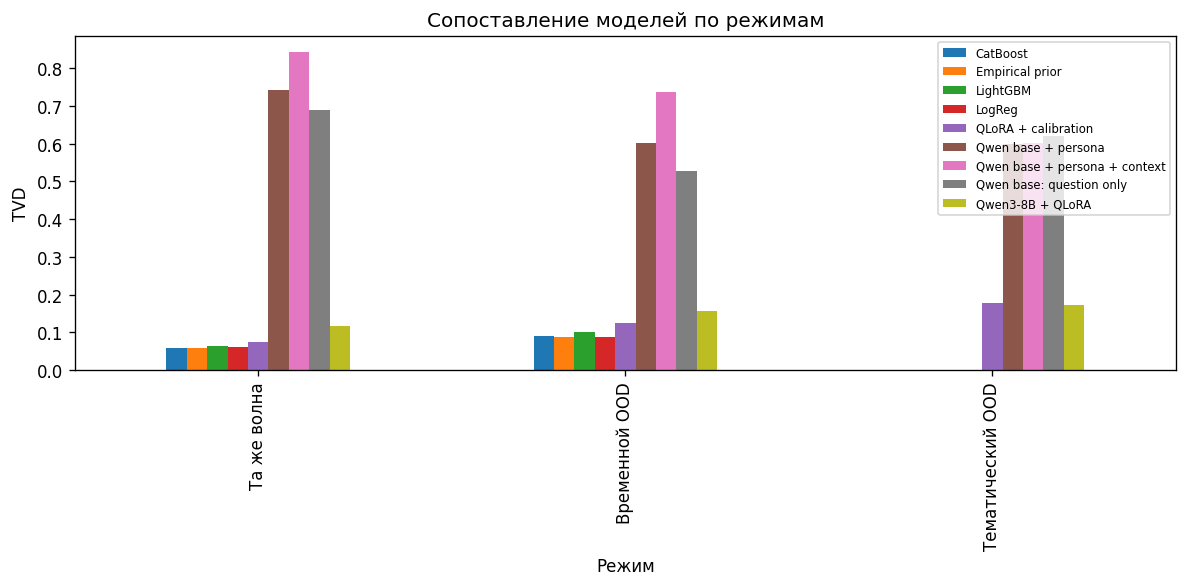

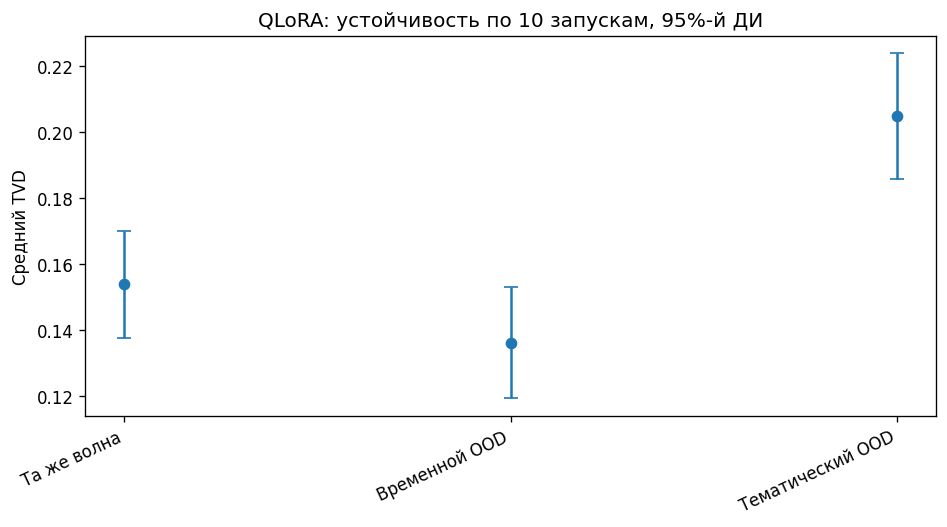

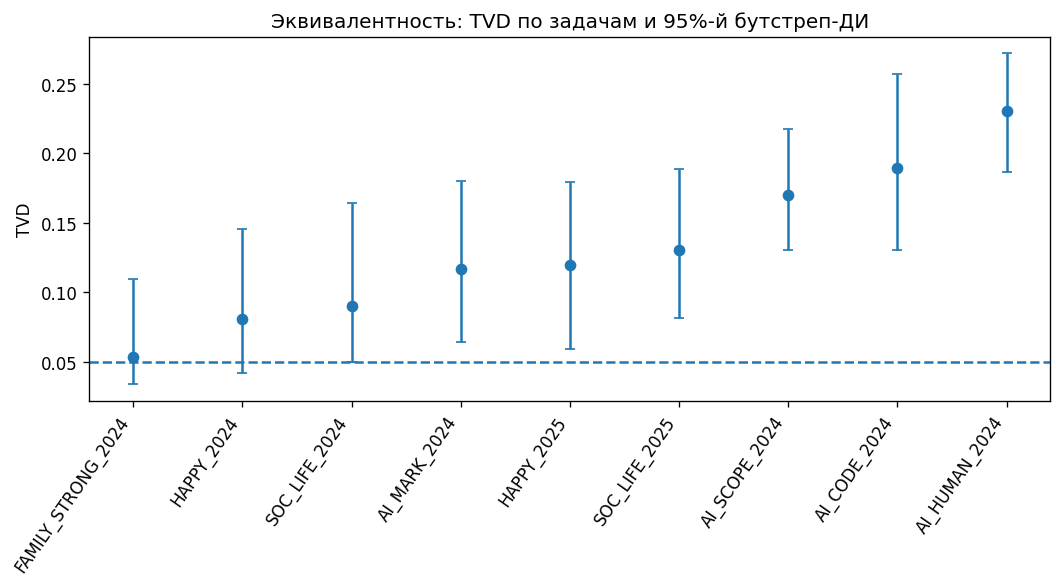

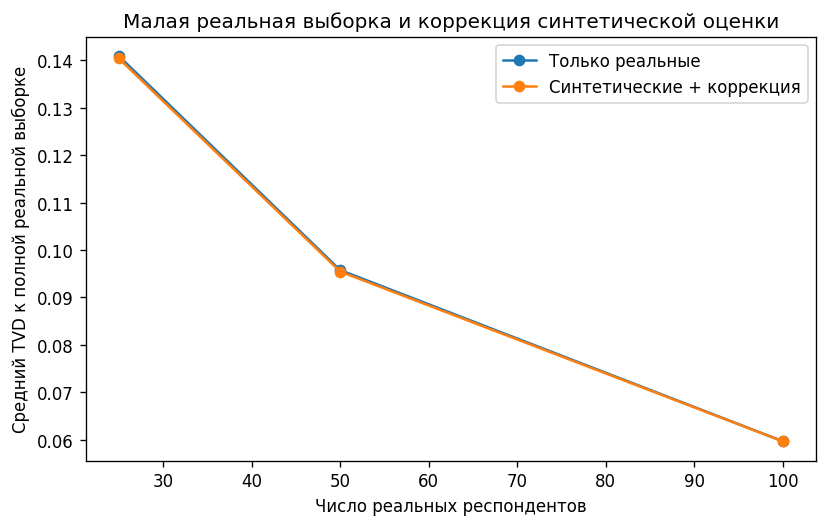

In [19]:
# Четыре основные публикационные фигуры. Остальные robustness-результаты остаются в Excel/archive.
# Matplotlib PDF-backend в текущем Colab может быть несовместим; PNG сохраняется Matplotlib, PDF при необходимости создаётся из PNG через Pillow.
from PIL import Image
FIG_DIR.mkdir(parents=True,exist_ok=True)
progress_set('save',0.0,'рисунок 1/4')
plt.rcParams.update({'font.size':10,'figure.dpi':120})

def savefig(name):
    fig=plt.gcf(); fig.tight_layout(); png=FIG_DIR/f'{name}.png'; pdf=FIG_DIR/f'{name}.pdf'
    fig.savefig(png,dpi=300,bbox_inches='tight')
    try:
        fig.savefig(pdf,bbox_inches='tight')
    except (ImportError,ModuleNotFoundError,AttributeError):
        with Image.open(png) as im:
            if im.mode!='RGB': im=im.convert('RGB')
            im.save(pdf,'PDF',resolution=300.0)
    plt.show(); plt.close(fig)
    if not png.exists() or not pdf.exists() or png.stat().st_size==0 or pdf.stat().st_size==0: raise RuntimeError(f'Не сохранён рисунок: {name}')

# Fig.1 — средний TVD по режимам и моделям.
piv=MODEL_COMPARISON.pivot(index='regime',columns='model',values='TVD').rename(index={'same_wave':'Та же волна','temporal_ood':'Временной OOD','thematic_ood':'Тематический OOD'})
ax=piv.plot(kind='bar',figsize=(10,5)); ax.set_xlabel('Режим'); ax.set_ylabel('TVD'); ax.set_title('Сопоставление моделей по режимам'); ax.legend(fontsize=7,loc='best')
savefig('Fig1_model_comparison_TVD'); progress_set('save',0.10,'рисунок 2/4')

# Fig.2 — robustness 10 seeds.
fig,ax=plt.subplots(figsize=(8,4.5)); x=np.arange(len(SEED_ROBUSTNESS)); y=SEED_ROBUSTNESS.mean_TVD.to_numpy(); err=np.vstack([y-SEED_ROBUSTNESS.CI95_low.to_numpy(),SEED_ROBUSTNESS.CI95_high.to_numpy()-y])
ax.errorbar(x,y,yerr=err,fmt='o',capsize=4); ax.set_xticks(x,SEED_ROBUSTNESS.regime.map({'same_wave':'Та же волна','temporal_ood':'Временной OOD','thematic_ood':'Тематический OOD'}),rotation=25,ha='right'); ax.set_ylabel('Средний TVD'); ax.set_title('QLoRA: устойчивость по 10 запускам, 95%-й ДИ')
savefig('Fig2_seed_robustness'); progress_set('save',0.20,'рисунок 3/4')

# Fig.3 — task-level equivalence.
fig,ax=plt.subplots(figsize=(9,5)); z=TASK_VALIDITY.sort_values('TVD').reset_index(drop=True); xx=np.arange(len(z))
lo=np.maximum(0,z.TVD.to_numpy()-z.TVD_CI_low.to_numpy()); hi=np.maximum(0,z.TVD_CI_high.to_numpy()-z.TVD.to_numpy())
ax.errorbar(xx,z.TVD.to_numpy(),yerr=np.vstack([lo,hi]),fmt='o',capsize=3); ax.axhline(EQUIV_TVD,linestyle='--'); ax.set_xticks(xx,z.task_id,rotation=55,ha='right'); ax.set_ylabel('TVD'); ax.set_title('Эквивалентность: TVD по задачам и 95%-й бутстреп-ДИ')
savefig('Fig3_equivalence_task_TVD'); progress_set('save',0.30,'рисунок 4/4')

# Fig.4 — human-only vs rectified.
z=RECTIFICATION.groupby(['n_real','method'],as_index=False).mean(numeric_only=True)
fig,ax=plt.subplots(figsize=(7,4.5))
method_ru={'human-only':'Только реальные','synthetic + human correction':'Синтетические + коррекция'}
for method,g in z.groupby('method'): ax.plot(g.n_real,g.mean_TVD,marker='o',label=method_ru.get(method,method))
ax.set_xlabel('Число реальных респондентов'); ax.set_ylabel('Средний TVD к полной реальной выборке'); ax.set_title('Малая реальная выборка и коррекция синтетической оценки'); ax.legend()
savefig('Fig4_rectification'); progress_set('save',0.40,'сохранение результатов')

In [20]:
# Финальный integrity gate: ничего не экспортируем, пока все обязательные результаты не завершены.
_required={'MODEL_COMPARISON':MODEL_COMPARISON,'SEED_ROBUSTNESS':SEED_ROBUSTNESS,'TASK_VALIDITY':TASK_VALIDITY,'SUBGROUP':SUBGROUP,'OPTION_ORDER':OPTION_ORDER,'SEQUENTIAL':SEQUENTIAL,'ASSOCIATION':ASSOCIATION,'RECTIFICATION':RECTIFICATION}
for _name,_df in _required.items():
    if not isinstance(_df,pd.DataFrame) or (_name not in {'SEQUENTIAL','ASSOCIATION'} and _df.empty): raise RuntimeError(f'Финальный export STOP: {_name} отсутствует/пуст.')
if SEED_RAW.seed.nunique()!=10: raise RuntimeError('Финальный export STOP: нет 10 seeds.')
if set(TASK_VALIDITY.task_id)!=set(s['task_id'] for s in TASK_SPECS): raise RuntimeError('Финальный export STOP: bootstrap не завершён для всех задач.')
if set(RECTIFICATION.task_id)!=set(s['task_id'] for s in TASK_SPECS): raise RuntimeError('Финальный export STOP: rectification не завершён для всех задач.')

# Компактное сохранение результатов и воспроизводимости.
CONFIG={
    'model_id':MODEL_ID,'chosen_qlora':CHOSEN_CONFIG,'canonical_seed':CANONICAL_SEED,'seeds':SEEDS,
    'gpu_name':GPU_NAME,'gpu_kind':GPU_KIND,'compute_profile':COMPUTE,
    'compute_budget_protocol':{'profile':'SAFE-FAST2X-V3','target_speedup':'~2x vs FAST-STABLE on L4 when 4x4 geometry passes probe; hardware-dependent','single_token_completion_loss':True,'liger_kernel':bool(LIGER_ENABLED),'persistent_frozen_base':True,'pooled_length_sorted_inference':True,'effective_batch':COMPUTE['effective_batch'],'train_bs':COMPUTE['train_bs'],'grad_accum':COMPUTE['grad_accum'],'gradient_checkpointing':COMPUTE.get('gradient_checkpointing',True),'final_epochs':CHOSEN_CONFIG['epochs'],'epoch2_material_threshold_TVD':EPOCH2_MATERIAL_TVD,'epoch2_validation_gain_TVD':EPOCH2_VALIDATION_GAIN,'epoch2_material':EPOCH2_MATERIAL,'google_drive':False},
    'equivalence':{'TVD':EQUIV_TVD,'max_pp':EQUIV_MAX_PP},
    'bootstrap_B':BOOTSTRAP_B,'rectification_B':RECTIFICATION_B,'temperature_canonical':CANONICAL_TEMP,
    'hp_sensitivity_validation':list(HP_LOG),'seed_train_stats':list(SEED_TRAIN_STATS),'sft_sample_sha256':SFT_SAMPLE_SHA256,'protocol_hash':PROTOCOL_HASH,
}

README=pd.DataFrame([
    ['purpose','Synthetic respondent experiment on open VCIOM microdata'],
    ['primary_metric','TVD'],
    ['equivalence','TVD<=0.05 AND max_pp<=5 pp with 95% CI inside margins'],
    ['target_selection','manual TASK_SPECS + checked physical hints; no fuzzy/semantic target auto-selection'],
    ['compute_profile','SAFE-FAST2X-V3: 10 seeds/data/statistics unchanged; exact checkpoints + Liger + adaptive microbatch + pooled inference'],
    ['storage','local runtime only; Google Drive is not mounted or used'],
    ['thematic_ood','ai_ethics_2024 excluded from SFT'],
    ['temporal_ood','2025 waves excluded from SFT'],
],columns=['field','value'])

source_meta=pd.DataFrame(DOWNLOAD_MANIFEST).copy()
for c in ['sav_paths','sha256']:
    if c in source_meta: source_meta[c]=source_meta[c].map(lambda x:json.dumps(x,ensure_ascii=False))
DATA_SHEET=DATA_AUDIT.merge(source_meta,left_on='dataset',right_on='dataset_id',how='left').drop(columns=['dataset_id'])
CONFIG_SHEET=pd.DataFrame([{'key':k,'value':json.dumps(v,ensure_ascii=False) if isinstance(v,(dict,list)) else v} for k,v in CONFIG.items()])

progress_set('save',0.45,'Excel')
xlsx=OUT_DIR/'experiment_results.xlsx'
with pd.ExcelWriter(xlsx,engine='openpyxl') as w:
    README.to_excel(w,'README',index=False)
    DATA_SHEET.to_excel(w,'DATA',index=False)
    CONFIG_SHEET.to_excel(w,'CONFIG',index=False)
    MODEL_COMPARISON.to_excel(w,'MODEL_COMPARISON',index=False)
    SEED_ROBUSTNESS.to_excel(w,'SEED_ROBUSTNESS',index=False)
    TASK_VALIDITY.to_excel(w,'TASK_VALIDITY',index=False)
    SUBGROUP.to_excel(w,'SUBGROUP',index=False)
    RECTIFICATION.to_excel(w,'RECTIFICATION',index=False)
    ROBUSTNESS.to_excel(w,'ROBUSTNESS',index=False)

progress_set('save',0.60,'Parquet + JSON manifests')
PREDICTIONS.to_parquet(OUT_DIR/'predictions.parquet',index=False)
(OUT_DIR/'config.json').write_text(json.dumps(CONFIG,ensure_ascii=False,indent=2),encoding='utf-8')

split_digest=hashlib.sha256(json.dumps({k:dict(sorted(v.items())) for k,v in sorted(SPLIT_MAPS.items())},ensure_ascii=False,sort_keys=True).encode()).hexdigest()
run_manifest={
    'created_utc':pd.Timestamp.utcnow().isoformat(),
    'datasets':DOWNLOAD_MANIFEST,
    'task_registry':TASK_REGISTRY.to_dict('records'),
    'task_bindings':{k:{**v,'code_to_idx':{str(kk):vv for kk,vv in v['code_to_idx'].items()}} for k,v in TASK_BINDINGS.items()},
    'validation_gate':VALIDATION_GATE.to_dict('records'),
    'split_sha256':split_digest,'sft_sample_sha256':SFT_SAMPLE_SHA256,
}
(OUT_DIR/'run_manifest.json').write_text(json.dumps(run_manifest,ensure_ascii=False,indent=2),encoding='utf-8')

pkgs=['torch','transformers','peft','bitsandbytes','accelerate','huggingface-hub','liger-kernel','pyreadstat','catboost','lightgbm','scikit-learn','pandas','numpy','scipy','openpyxl','pyarrow']
def ver(name):
    try:
        import importlib.metadata as md; return md.version(name)
    except Exception: return 'unknown'
try: git_hash=subprocess.check_output(['git','rev-parse','HEAD'],stderr=subprocess.DEVNULL,text=True).strip()
except Exception: git_hash='not available'
env=['Python: '+sys.version.replace('\n',' '),'Platform: '+platform.platform(),'GPU: '+GPU_NAME,'CUDA: '+str(torch.version.cuda),'Git commit: '+git_hash]
env += [f'{p}: {ver(p)}' for p in pkgs]
(OUT_DIR/'environment.txt').write_text('\n'.join(env),encoding='utf-8')

SOURCES_GOST="""
ВЦИОМ. Социальное самочувствие: мониторинг [Электронный ресурс]. 20.03.2024. URL: https://wciom.ru/analytical-reviews/analiticheskii-obzor/socialnoe-samochuvstvie-monitoring-20032024 (дата обращения: 18.09.2026).
ВЦИОМ. Социальное самочувствие россиян: мониторинг [Электронный ресурс]. 27.05.2025. URL: https://wciom.ru/analytical-reviews/analiticheskii-obzor/socialnoe-samochuvstvie-rossijan-monitoring-27052025 (дата обращения: 18.09.2026).
ВЦИОМ. Этика искусственного интеллекта [Электронный ресурс]. 03.09.2024. URL: https://wciom.ru/analytical-reviews/analiticheskii-obzor/ehtika-iskusstvennogo-intellekta-2 (дата обращения: 18.09.2026).
ВЦИОМ. Семья в системе ценностей россиян [Электронный ресурс]. 06.06.2024. URL: https://wciom.ru/analytical-reviews/analiticheskii-obzor/semja-v-sisteme-cennostei-rossijan (дата обращения: 18.09.2026).
ВЦИОМ. Счастье в России: мониторинг [Электронный ресурс]. 18.04.2024. URL: https://wciom.ru/analytical-reviews/analiticheskii-obzor/schaste-v-rossii-monitoring-18042024 (дата обращения: 18.09.2026).
ВЦИОМ. Счастье в России: мониторинг [Электронный ресурс]. 16.04.2025. URL: https://wciom.ru/analytical-reviews/analiticheskii-obzor/schaste-v-rossii-monitoring-16042025 (дата обращения: 18.09.2026).
Qwen Team. Qwen3-8B [Электронный ресурс]. Hugging Face. URL: https://huggingface.co/Qwen/Qwen3-8B (дата обращения: 18.09.2026).
Hsu P.-L., Dai Y., Kothapalli V. et al. Liger-Kernel: Efficient Triton Kernels for LLM Training // Championing Open-source Development in ML Workshop @ ICML 2025. URL: https://openreview.net/forum?id=36SjAIT42G.
Argyle L.P., Busby E.C., Fulda N., Gubler J.R., Rytting C., Wingate D. Out of One, Many: Using Language Models to Simulate Human Samples // Political Analysis. 2023. Vol. 31, No. 3. P. 337–351. DOI: 10.1017/pan.2023.2.
Bisbee J., Clinton J.D., Dorff C., Kenkel B., Larson J.M. Synthetic Replacements for Human Survey Data? The Perils of Large Language Models // Political Analysis. 2024. Vol. 32, No. 4. P. 401–416. DOI: 10.1017/pan.2024.5.
Santurkar S., Durmus E., Ladhak F., Lee C., Liang P., Hashimoto T. Whose Opinions Do Language Models Reflect? // Proceedings of the 40th International Conference on Machine Learning. PMLR 202. 2023. P. 29971–30004. URL: https://proceedings.mlr.press/v202/santurkar23a.html.
Ma B., Wang X., Hu T., Haensch A.-C., Hedderich M.A., Plank B., Kreuter F. The Potential and Challenges of Evaluating Attitudes, Opinions, and Values in Large Language Models // Findings of EMNLP 2024. P. 8783–8805. DOI: 10.18653/v1/2024.findings-emnlp.513.
Suh J., Jahanparast E., Moon S., Kang M., Chang S. Language Model Fine-Tuning on Scaled Survey Data for Predicting Distributions of Public Opinions // Proceedings of ACL 2025. P. 21147–21170. DOI: 10.18653/v1/2025.acl-long.1028.
Krsteski S., Russo G., Chang S., West R., Gligorić K. Valid Survey Simulations with Limited Human Data: The Roles of Prompting, Fine-Tuning, and Rectification // Proceedings of ACL 2026. P. 10887–10906. DOI: 10.18653/v1/2026.acl-long.498.
Angelopoulos A.N., Bates S., Fannjiang C., Jordan M.I., Zrnic T. Prediction-powered inference // Science. 2023. Vol. 382, No. 6671. P. 669–674. DOI: 10.1126/science.adi6000.
Wei S.-L., Wu C.-K., Huang H.-H., Chen H.-H. Unveiling Selection Biases: Exploring Order and Token Sensitivity in Large Language Models // Findings of ACL 2024. P. 5598–5621. DOI: 10.18653/v1/2024.findings-acl.333.
""".strip()
(OUT_DIR/'sources_GOST.txt').write_text(SOURCES_GOST,encoding='utf-8')

progress_set('save',0.82,'финальный ZIP')
archive=OUT_DIR/'synthetic_respondents_vciom_results.zip'
with zipfile.ZipFile(archive,'w',compression=zipfile.ZIP_DEFLATED) as z:
    fixed=[xlsx,OUT_DIR/'predictions.parquet',OUT_DIR/'config.json',OUT_DIR/'run_manifest.json',OUT_DIR/'environment.txt',OUT_DIR/'sources_GOST.txt']
    for p in fixed:
        if not p.exists(): raise RuntimeError(f'Не создан обязательный файл: {p.name}')
        z.write(p,p.relative_to(OUT_DIR))
    for p in FIG_DIR.glob('*'): z.write(p,p.relative_to(OUT_DIR))
    for p in ADAPTER_DIR.rglob('*'):
        if p.is_file(): z.write(p,p.relative_to(OUT_DIR))

# Одинаковые evaluation respondents для всех моделей, которые сравниваются на одной задаче.
for tid,g in PREDICTIONS.groupby('task_id'):
    sets=[set(x.respondent_id.astype(str)) for _,x in g.groupby('model')]
    if sets and not all(s==sets[0] for s in sets): raise RuntimeError(f'Разные evaluation respondents между моделями: {tid}')

progress_set('save',0.99,'финальная проверка outputs'); progress_done()

print('FINAL VERDICT')
eq=int(TASK_VALIDITY.equivalent.sum()); total=len(TASK_VALIDITY)
print(f'Эквивалентность по строгому CI-критерию: {eq}/{total} задач.')
q=MODEL_COMPARISON[MODEL_COMPARISON.model.eq('QLoRA + calibration')][['regime','TVD','max_pp']].sort_values('regime')
for _,r in q.iterrows(): print(f"{r.regime}: TVD={r.TVD:.3f}, max_pp={r.max_pp:.1f} п.п.")
rr=RECTIFICATION.groupby(['n_real','method'],as_index=False).mean(numeric_only=True)
if len(rr):
    p=rr.pivot(index='n_real',columns='method',values='mean_TVD')
    if {'human-only','synthetic + human correction'}.issubset(p.columns):
        print('Rectification: '+', '.join(f'n={i}: ΔTVD={(p.loc[i,"synthetic + human correction"]-p.loc[i,"human-only"]):+.3f}' for i in p.index))
print(f'Результаты сохранены: {archive}')


FINAL VERDICT
Эквивалентность по строгому CI-критерию: 0/9 задач.
same_wave: TVD=0.075, max_pp=5.2 п.п.
temporal_ood: TVD=0.125, max_pp=9.1 п.п.
thematic_ood: TVD=0.177, max_pp=14.5 п.п.
Rectification: n=25: ΔTVD=-0.001, n=50: ΔTVD=-0.000, n=100: ΔTVD=-0.000
Результаты сохранены: /content/vciom_synthetic_respondents/outputs_SAFE_FAST2X_V3_20260918/synthetic_respondents_vciom_results.zip


In [21]:
# === SCIENTIFIC REPORT EXPORT: один компактный XLSX, без служебных файлов ===
from pathlib import Path
import pandas as pd, numpy as np, os, json
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image as XLImage

REPORT_FILE=Path('/content/VCIOM_Synthetic_Respondents_SCIENTIFIC_RESULTS.xlsx')

# 1. Краткое резюме эксперимента.
summary=[]
def add(k,v): summary.append({'Показатель':k,'Значение':v})
add('Модель','Qwen/Qwen3-8B + QLoRA')
add('Число независимых seed-runs',len(SEEDS) if 'SEEDS' in globals() else '')
add('Canonical seed',CANONICAL_SEED if 'CANONICAL_SEED' in globals() else '')
add('Bootstrap iterations',BOOTSTRAP_B if 'BOOTSTRAP_B' in globals() else '')
add('Rectification iterations',RECTIFICATION_B if 'RECTIFICATION_B' in globals() else '')
add('Критерий эквивалентности TVD',EQUIV_TVD if 'EQUIV_TVD' in globals() else '')
add('Критерий эквивалентности max_pp',EQUIV_MAX_PP if 'EQUIV_MAX_PP' in globals() else '')
if 'CHOSEN_CONFIG' in globals():
    add('QLoRA learning rate',CHOSEN_CONFIG.get('lr','')); add('QLoRA rank',CHOSEN_CONFIG.get('rank','')); add('QLoRA epochs',CHOSEN_CONFIG.get('epochs',''))
if 'TASK_VALIDITY' in globals() and len(TASK_VALIDITY):
    add('Эквивалентных задач',f"{int(TASK_VALIDITY['equivalent'].sum())} / {len(TASK_VALIDITY)}")
if 'MODEL_COMPARISON' in globals() and len(MODEL_COMPARISON):
    q=MODEL_COMPARISON[MODEL_COMPARISON.model.eq('QLoRA + calibration')]
    if len(q): add('Средний TVD QLoRA + calibration',round(float(q.TVD.mean()),4))
if 'SEED_ROBUSTNESS' in globals() and len(SEED_ROBUSTNESS):
    add('Средний TVD по 10 seeds',round(float(SEED_ROBUSTNESS.mean_TVD.mean()),4))
SUMMARY=pd.DataFrame(summary)

# 2. Только научно значимые итоговые таблицы.
tables={
    'SUMMARY':SUMMARY,
    'MODEL_COMPARISON':globals().get('MODEL_COMPARISON'),
    'TASK_RESULTS':globals().get('MODEL_COMPARISON_TASK'),
    'SEED_ROBUSTNESS':globals().get('SEED_ROBUSTNESS'),
    'EQUIVALENCE':globals().get('TASK_VALIDITY'),
    'SUBGROUP':globals().get('SUBGROUP'),
    'RECTIFICATION':globals().get('RECTIFICATION'),
    'OPTION_ORDER':globals().get('OPTION_ORDER'),
    'SEQUENTIAL':globals().get('SEQUENTIAL'),
    'ASSOCIATION':globals().get('ASSOCIATION'),
}
tables={k:v for k,v in tables.items() if isinstance(v,pd.DataFrame) and not v.empty}

with pd.ExcelWriter(REPORT_FILE,engine='openpyxl') as writer:
    for name,df in tables.items(): df.to_excel(writer,sheet_name=name,index=False)

# 3. Аккуратное форматирование книги.
wb=load_workbook(REPORT_FILE)
for ws in wb.worksheets:
    ws.freeze_panes='A2'; ws.auto_filter.ref=ws.dimensions
    for c in ws[1]:
        c.font=Font(bold=True); c.fill=PatternFill('solid',fgColor='D9E2F3'); c.alignment=Alignment(horizontal='center',vertical='center',wrap_text=True)
    for col in range(1,ws.max_column+1):
        vals=[str(ws.cell(r,col).value or '') for r in range(1,min(ws.max_row,200)+1)]
        ws.column_dimensions[get_column_letter(col)].width=min(max(11,max(map(len,vals),default=8)+2),42)
    for row in ws.iter_rows():
        for c in row: c.alignment=Alignment(vertical='top',wrap_text=True)

# 4. Четыре основных рисунка внутрь того же XLSX.
fig_candidates=[
    ('Fig1_model_comparison_TVD.png','Fig. 1. Сопоставление моделей по режимам'),
    ('Fig2_seed_robustness.png','Fig. 2. Устойчивость QLoRA по seed-runs'),
    ('Fig3_equivalence_task_TVD.png','Fig. 3. Эквивалентность по задачам'),
    ('Fig4_rectification.png','Fig. 4. Human-only и synthetic + correction'),
]
fig_dir=globals().get('FIG_DIR',Path('/content'))
existing=[]
for fn,title in fig_candidates:
    p=Path(fig_dir)/fn
    if p.exists() and p.stat().st_size>0: existing.append((p,title))
if existing:
    ws=wb.create_sheet('FIGURES'); row=1
    for p,title in existing:
        ws.cell(row,1,title).font=Font(bold=True,size=12); img=XLImage(str(p)); img.width=min(img.width,900); img.height=int(img.height*(img.width/min(img.width,900))) if img.width else img.height
        ws.add_image(img,f'A{row+1}'); row+=32
    ws.column_dimensions['A'].width=120

# 5. Контроль целостности и сохранение.
wb.save(REPORT_FILE)
assert REPORT_FILE.exists() and REPORT_FILE.stat().st_size>10_000
print(f'✓ Научные результаты сохранены: {REPORT_FILE.name} · {REPORT_FILE.stat().st_size/1024/1024:.2f} MB · sheets={len(wb.sheetnames)}')

# 6. Скачать пользователю одним файлом.
try:
    from google.colab import files
    files.download(str(REPORT_FILE))
except Exception:
    print(f'Файл готов: {REPORT_FILE}')

✓ Научные результаты сохранены: VCIOM_Synthetic_Respondents_SCIENTIFIC_RESULTS.xlsx · 0.52 MB · sheets=11


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Источники данных и программных моделей

1. ВЦИОМ. **Социальное самочувствие: мониторинг** [Электронный ресурс]. 20.03.2024. URL: https://wciom.ru/analytical-reviews/analiticheskii-obzor/socialnoe-samochuvstvie-monitoring-20032024 (дата обращения: 18.09.2026).
2. ВЦИОМ. **Социальное самочувствие россиян: мониторинг** [Электронный ресурс]. 27.05.2025. URL: https://wciom.ru/analytical-reviews/analiticheskii-obzor/socialnoe-samochuvstvie-rossijan-monitoring-27052025 (дата обращения: 18.09.2026).
3. ВЦИОМ. **Этика искусственного интеллекта** [Электронный ресурс]. 03.09.2024. URL: https://wciom.ru/analytical-reviews/analiticheskii-obzor/ehtika-iskusstvennogo-intellekta-2 (дата обращения: 18.09.2026).
4. ВЦИОМ. **Семья в системе ценностей россиян** [Электронный ресурс]. 06.06.2024. URL: https://wciom.ru/analytical-reviews/analiticheskii-obzor/semja-v-sisteme-cennostei-rossijan (дата обращения: 18.09.2026).
5. ВЦИОМ. **Счастье в России: мониторинг** [Электронный ресурс]. 18.04.2024. URL: https://wciom.ru/analytical-reviews/analiticheskii-obzor/schaste-v-rossii-monitoring-18042024 (дата обращения: 18.09.2026).
6. ВЦИОМ. **Счастье в России: мониторинг** [Электронный ресурс]. 16.04.2025. URL: https://wciom.ru/analytical-reviews/analiticheskii-obzor/schaste-v-rossii-monitoring-16042025 (дата обращения: 18.09.2026).
7. Qwen Team. **Qwen3-8B** [Электронный ресурс]. Hugging Face. URL: https://huggingface.co/Qwen/Qwen3-8B (дата обращения: 18.09.2026).
8. Hsu P.-L., Dai Y., Kothapalli V. et al. **Liger-Kernel: Efficient Triton Kernels for LLM Training** // Championing Open-source Development in ML Workshop @ ICML 2025. URL: https://openreview.net/forum?id=36SjAIT42G.
9. Argyle L. P., Busby E. C., Fulda N., Gubler J. R., Rytting C., Wingate D. Out of One, Many: Using Language Models to Simulate Human Samples // *Political Analysis*. 2023. Vol. 31, No. 3. P. 337–351. DOI: 10.1017/pan.2023.2.
10. Bisbee J., Clinton J. D., Dorff C., Kenkel B., Larson J. M. Synthetic Replacements for Human Survey Data? The Perils of Large Language Models // *Political Analysis*. 2024. Vol. 32, No. 4. P. 401–416. DOI: 10.1017/pan.2024.5.
11. Santurkar S., Durmus E., Ladhak F., Lee C., Liang P., Hashimoto T. Whose Opinions Do Language Models Reflect? // *Proceedings of the 40th International Conference on Machine Learning*. PMLR 202. 2023. P. 29971–30004. URL: https://proceedings.mlr.press/v202/santurkar23a.html.
12. Ma B., Wang X., Hu T., Haensch A.-C., Hedderich M. A., Plank B., Kreuter F. The Potential and Challenges of Evaluating Attitudes, Opinions, and Values in Large Language Models // *Findings of EMNLP 2024*. P. 8783–8805. DOI: 10.18653/v1/2024.findings-emnlp.513.
13. Suh J., Jahanparast E., Moon S., Kang M., Chang S. Language Model Fine-Tuning on Scaled Survey Data for Predicting Distributions of Public Opinions // *Proceedings of ACL 2025*. P. 21147–21170. DOI: 10.18653/v1/2025.acl-long.1028.
14. Krsteski S., Russo G., Chang S., West R., Gligorić K. Valid Survey Simulations with Limited Human Data: The Roles of Prompting, Fine-Tuning, and Rectification // *Proceedings of ACL 2026*. P. 10887–10906. DOI: 10.18653/v1/2026.acl-long.498.
15. Angelopoulos A. N., Bates S., Fannjiang C., Jordan M. I., Zrnic T. Prediction-powered inference // *Science*. 2023. Vol. 382, No. 6671. P. 669–674. DOI: 10.1126/science.adi6000.
16. Wei S.-L., Wu C.-K., Huang H.-H., Chen H.-H. Unveiling Selection Biases: Exploring Order and Token Sensitivity in Large Language Models // *Findings of ACL 2024*. P. 5598–5621. DOI: 10.18653/v1/2024.findings-acl.333.
